# Encoder-Decoder Architecture for Sequence-to-Sequence Data

## Study Notes

---

# Topic 1: Introduction to Sequence-to-Sequence Problems

## 1. Introduction

**What it is:**
Sequence-to-sequence (Seq2Seq) problems are tasks where **both the input and output are sequences** of data. Unlike previous challenges where input was tabular (ANN) or image-based (CNN), or where only input was sequential (RNN/LSTM), Seq2Seq requires handling sequences on both ends.

**Why it's important:**
- Foundation for understanding modern Large Language Models (LLMs)
- Essential for machine translation, text summarization, question answering, and chatbots
- Bridges the gap between understanding single sequences and generating new sequences

**Real-life uses:**
- **Machine Translation**: English → Hindi, English → French
- **Text Summarization**: Long article → Short summary
- **Chatbots**: User query → Bot response
- **Speech Recognition**: Audio → Text transcription

---

## 2. Detailed Explanation

### The Three Challenges of Seq2Seq Data

| Challenge | Description | Example |
|-----------|-------------|---------|
| **Variable Input Length** | Input sentences can be 2 words or 200 words | "Hi" vs. "The quick brown fox jumps over the lazy dog" |
| **Variable Output Length** | Output sentences also vary in length | Translation can be shorter or longer |
| **No Length Correspondence** | Input words ≠ Output words | "Nice to meet you" (4 words) → "आपसे मिलकर अच्छा लगा" (6 words in Hindi) |

### Why CNNs Failed for Sequential Data

CNNs process data as fixed-size grids:
- **Tabular data**: 2D grid (rows × columns)
- **Image data**: 3D grid (height × width × channels)
- **Sequential data**: The **order/sequence has meaning** that CNNs cannot capture

The order of words in a sentence completely changes the meaning:
- "Dog bites man" ≠ "Man bites dog"

### Why RNNs/LSTMs Weren't Enough

We studied RNNs, LSTMs, and GRUs to handle **input sequences**, but they only solved:
- ✅ Variable length input
- ❌ Variable length output (they couldn't generate sequences of arbitrary length)
- ❌ Input-output length mismatch

---

## 3. Key Points

- **Seq2Seq problems**: Input is sequential AND output is sequential
- **Three core challenges**: Variable input length, variable output length, no fixed correspondence between input/output lengths
- **Common examples**: Machine translation, summarization, chatbots
- **Prerequisite knowledge**: RNNs, LSTMs, and GRUs
- **Why it's foundational**: Understanding Seq2Seq is essential for grasping Transformers and LLMs

---

## 4. Revision Notes

- Seq2Seq tackles problems where **both sides are sequences**
- Three challenges: variable input, variable output, mismatched lengths
- RNN/LSTM handles variable input but NOT variable output generation
- Real-world use: Google Translate, chatbots, voice assistants
- This architecture is the **starting point** for understanding modern LLMs

---



# Topic 2: High-Level Overview of Encoder-Decoder Architecture
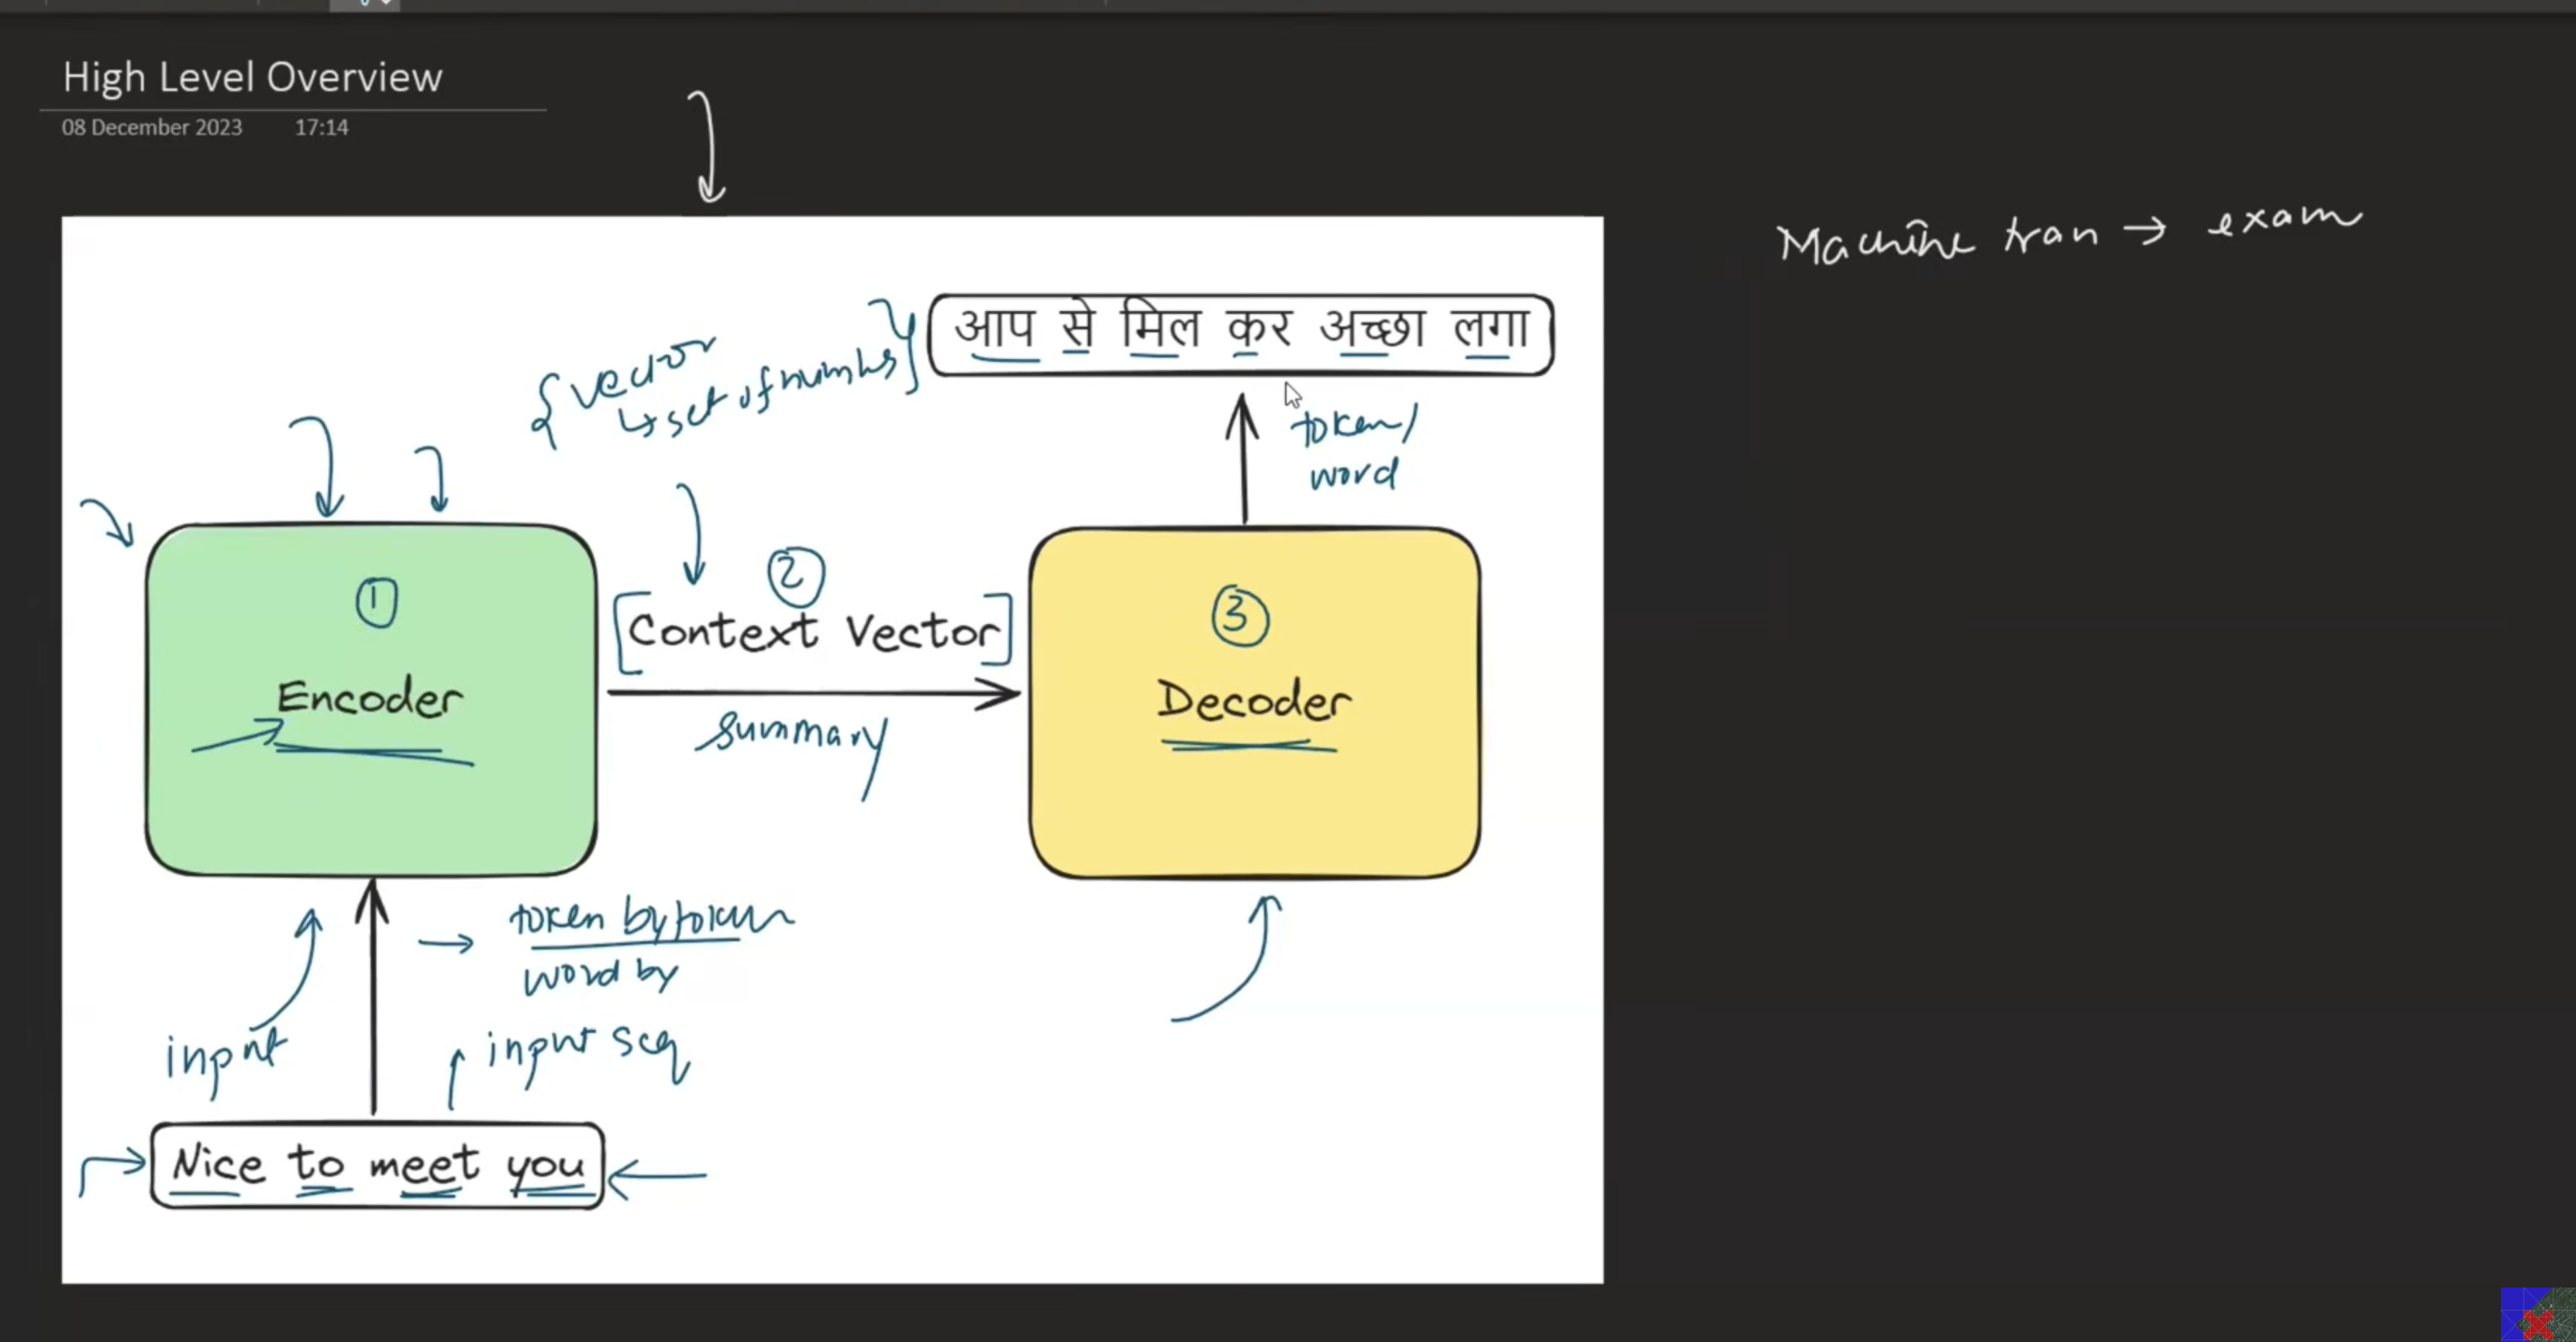
---

## 1. Introduction

The Encoder-Decoder architecture is the foundational solution for sequence-to-sequence problems. Its beauty lies in its **simplicity at a high level** — it consists of just two main blocks connected by a "context vector." This modular design separates the task into two clear responsibilities: **understanding** the input and **generating** the output.

---

## 2. Detailed Explanation

### The Three Core Components

```
┌─────────────────────────────────────────────────────────────────┐
│                    ENCODER-DECODER ARCHITECTURE                 │
│                                                                  │
│   INPUT SEQUENCE          CONTEXT VECTOR      OUTPUT SEQUENCE   │
│   ┌─────────────┐        ┌───────────┐       ┌─────────────┐   │
│   │             │        │           │       │             │   │
│   │  ENCODER   │───────▶│  CONTEXT  │──────▶│  DECODER   │   │
│   │             │        │  VECTOR   │       │             │   │
│   │  (LSTM)    │        │           │       │  (LSTM)    │   │
│   └─────────────┘        └───────────┘       └─────────────┘   │
│                                                                  │
│   "nice"→"to"→"meet"→"you"   [numbers]       "नाइस"→"टू"→...   │
└─────────────────────────────────────────────────────────────────┘
```

### Component 1: The Encoder

| Aspect | Explanation |
|--------|-------------|
| **Role** | Understand the input sequence and create a summary |
| **Input** | Source sentence provided **word-by-word** (token by token) |
| **Process** | Each word updates the internal state; after processing all words, it produces a final representation |
| **Output** | A **context vector** — a set of numbers representing the summary of the entire input sentence |
| **Analogy** | Like reading a book and summarizing it into a few sentences |

**Example:**
- Input: "nice" → "to" → "meet" → "you" (word by word)
- Encoder processes each word sequentially
- Final output: A context vector like `[0.23, -0.45, 0.67, ...]` (just numbers!)

### Component 2: The Context Vector

| Aspect | Explanation |
|--------|-------------|
| **Role** | Bridge between encoder and decoder |
| **What it is** | The final hidden states (h<sub>t</sub> and c<sub>t</sub>) from the encoder's last time step |
| **Purpose** | Carries the "essence" or "summary" of the entire input sequence |
| **Analogy** | Like the "gist" you remember after reading a sentence — you don't remember each word, but you understand the meaning |

### Component 3: The Decoder

| Aspect | Explanation |
|--------|-------------|
| **Role** | Generate the output sequence based on the context vector |
| **Input** | Context vector from encoder + special "start" token to begin |
| **Process** | Generates one word at a time, feeding each output back as input for the next step |
| **Output** | Target sequence in the desired language |
| **Analogy** | Like taking a book summary and writing it in a different language, word by word |

**Output Generation Flow:**
1. Start token (`<start>`) is given as input
2. Decoder generates first word
3. First word becomes input for second time step
4. Process continues until ` <end>` token is generated
5. Decoder stops producing output

---

## 3. Key Points

- Encoder-Decoder has **three parts**: Encoder, Context Vector, Decoder
- Encoder **summarizes** the input into a context vector
- Context vector is a **set of numbers** representing the entire input
- Decoder **generates** output word-by-word
- Output generation starts with a `<start>` token and stops with an `<end>` token
- The architecture elegantly **separates understanding from generation**

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Approach |
|---------|----------------|------------------|
| Thinking encoder and decoder share weights | They are two separate LSTMs with different parameters | They are **independent** neural networks |
| Assuming input and output lengths must match | Length correspondence is NOT guaranteed | Decoder stops only when it generates `<end>` |
| Forgetting the start token | Decoder needs a "trigger" to begin | Always provide `<start>` as first decoder input |
| Thinking context vector is human-readable | It's just numbers | It's a mathematical representation, not text |

---

## 5. Interview/Exam Questions

**Q1: What are the three main components of an encoder-decoder architecture?**
> **Answer:** Encoder, Context Vector (or Context), and Decoder. The encoder processes the input sequence and produces a context vector; the context vector carries the summary; the decoder uses this summary to generate the output sequence.

**Q2: Why do we need both a `<start>` and `<end>` token?**
> **Answer:** The `<start>` token tells the decoder when to begin generating output (it has no other way to know). The `<end>` token tells the decoder when to stop — without it, the decoder would continue generating indefinitely.

**Q3: What is a context vector?**
> **Answer:** It's the final hidden state(s) of the encoder — a fixed-size vector that summarizes the entire input sequence. It contains all the information the decoder needs to generate the output.

**Q4: How does the decoder know how long the output should be?**
> **Answer:** It doesn't know in advance. It keeps generating words one by one until it produces the `<end>` token, at which point it stops.

---

## 6. Revision Notes

- **Encoder**: Reads input → produces context vector
- **Context vector**: Numerical summary of input
- **Decoder**: Starts with `<start>` → generates words → stops at `<end>`
- Encoder and decoder are **separate LSTMs** (different weights)
- Input is word-by-word; output is also word-by-word
- Architecture separates **understanding** from **generation**

---



# Topic 3: Encoder and Decoder Internal Architecture (LSTM Details)
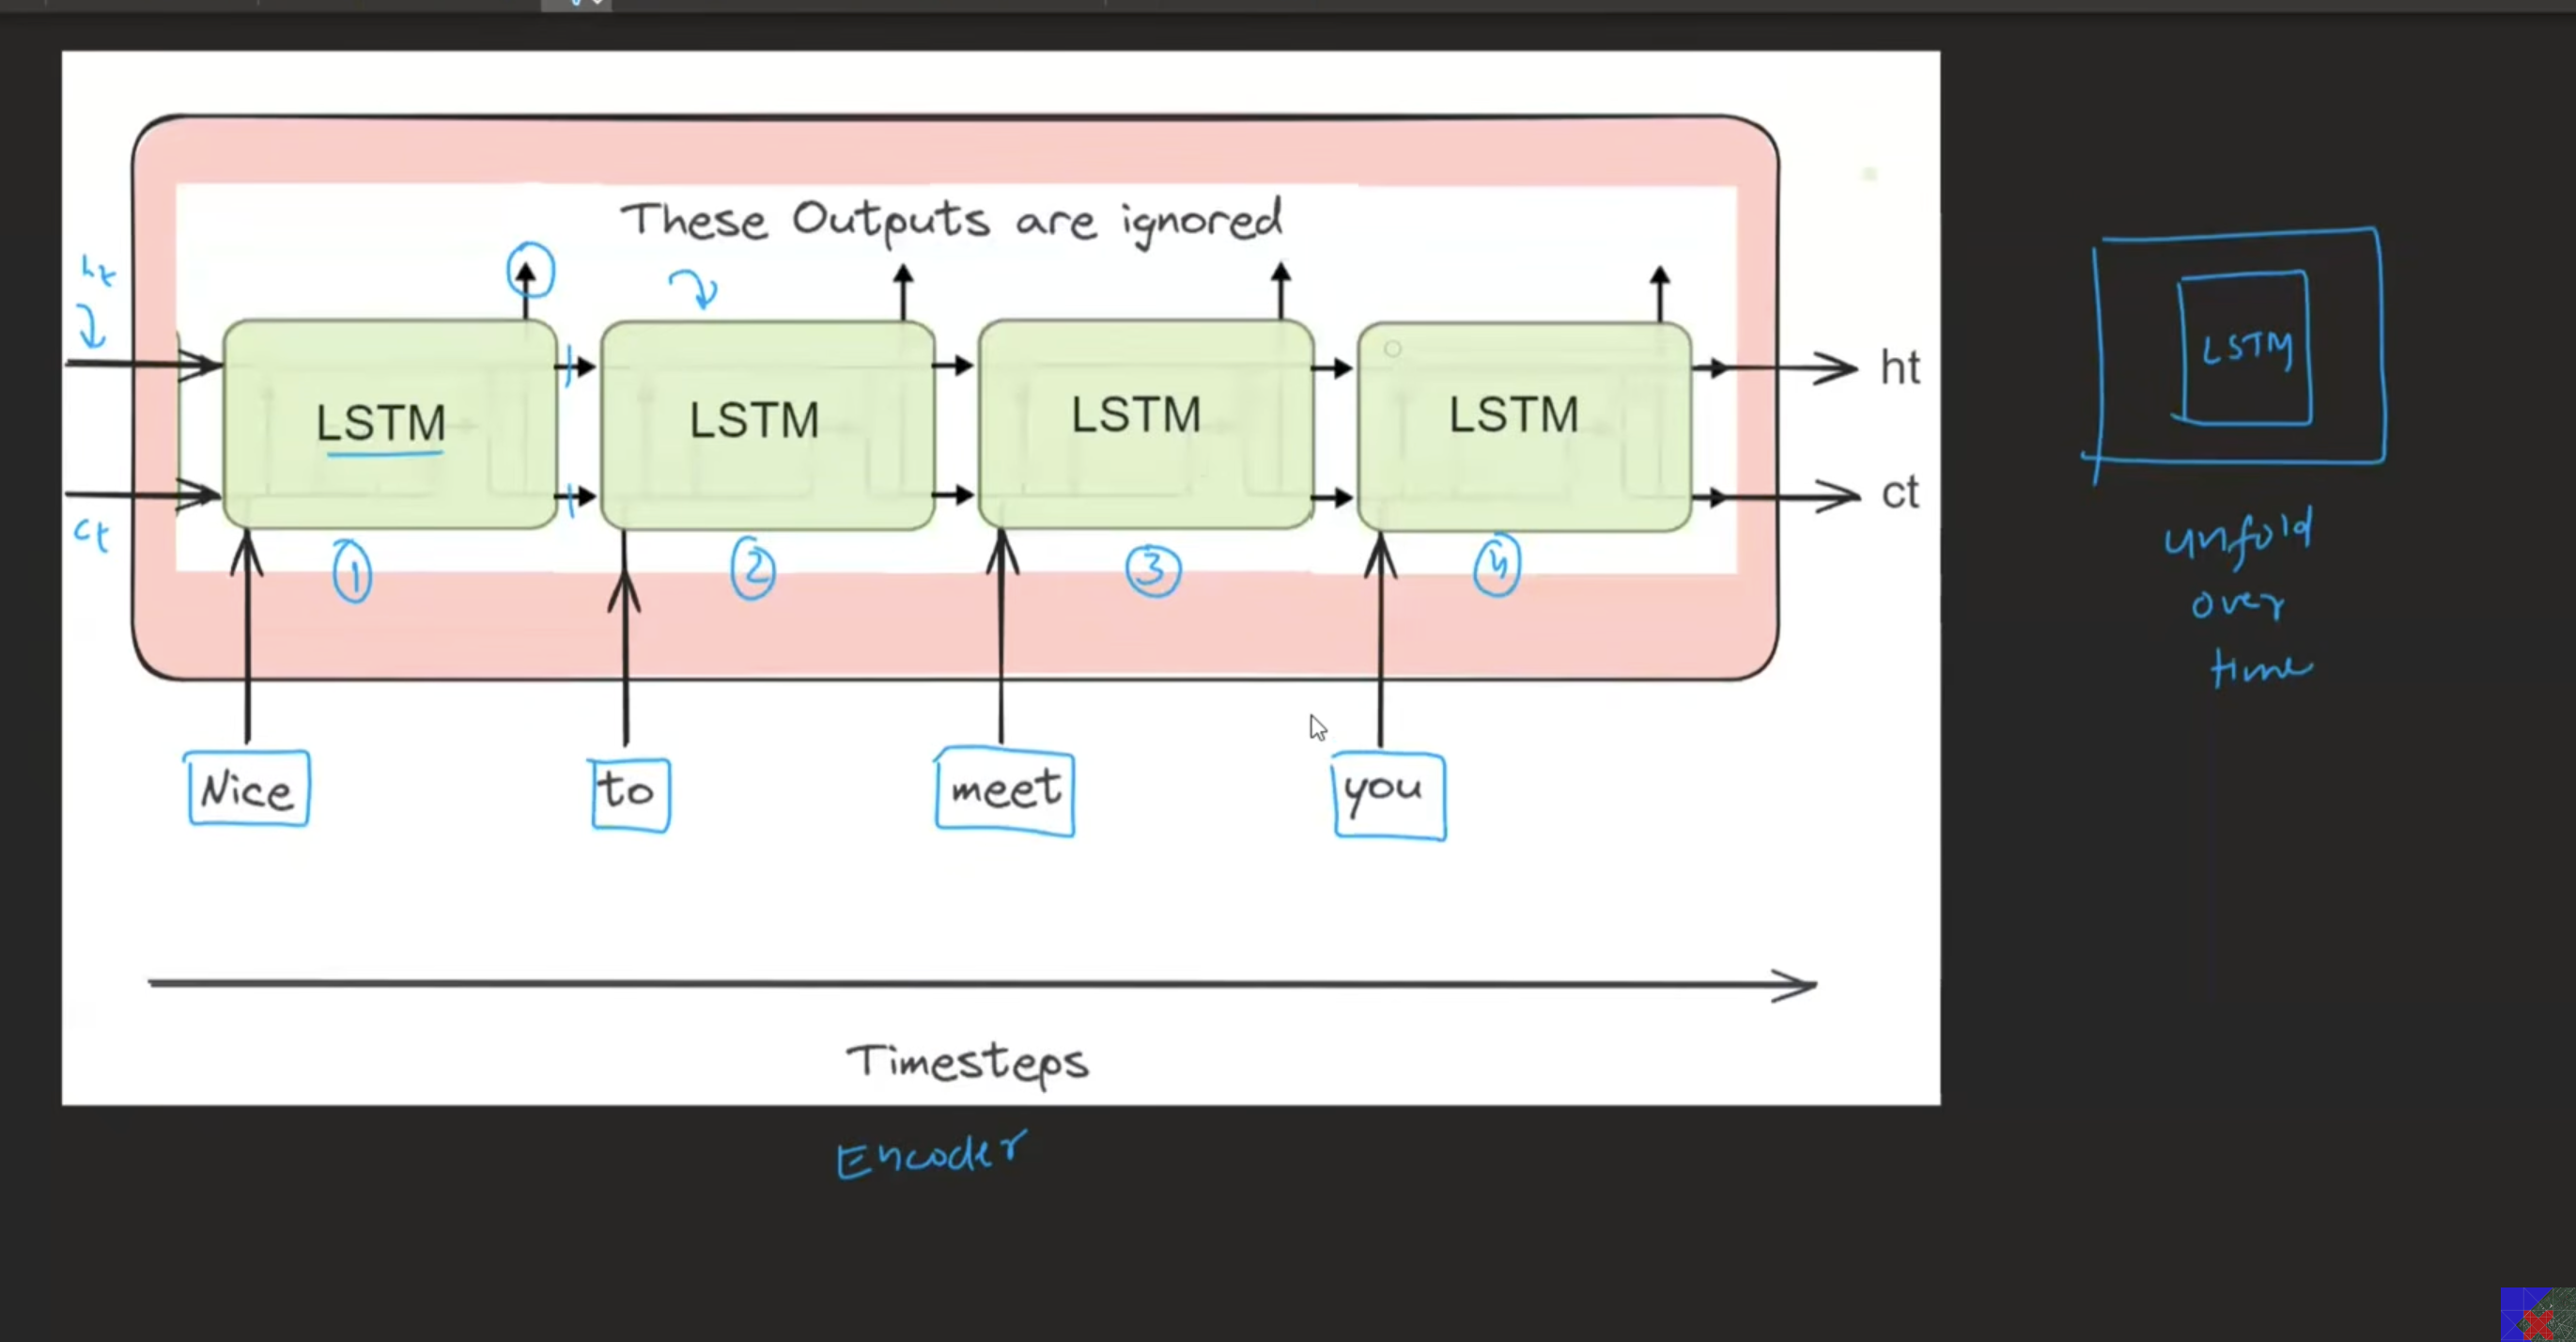
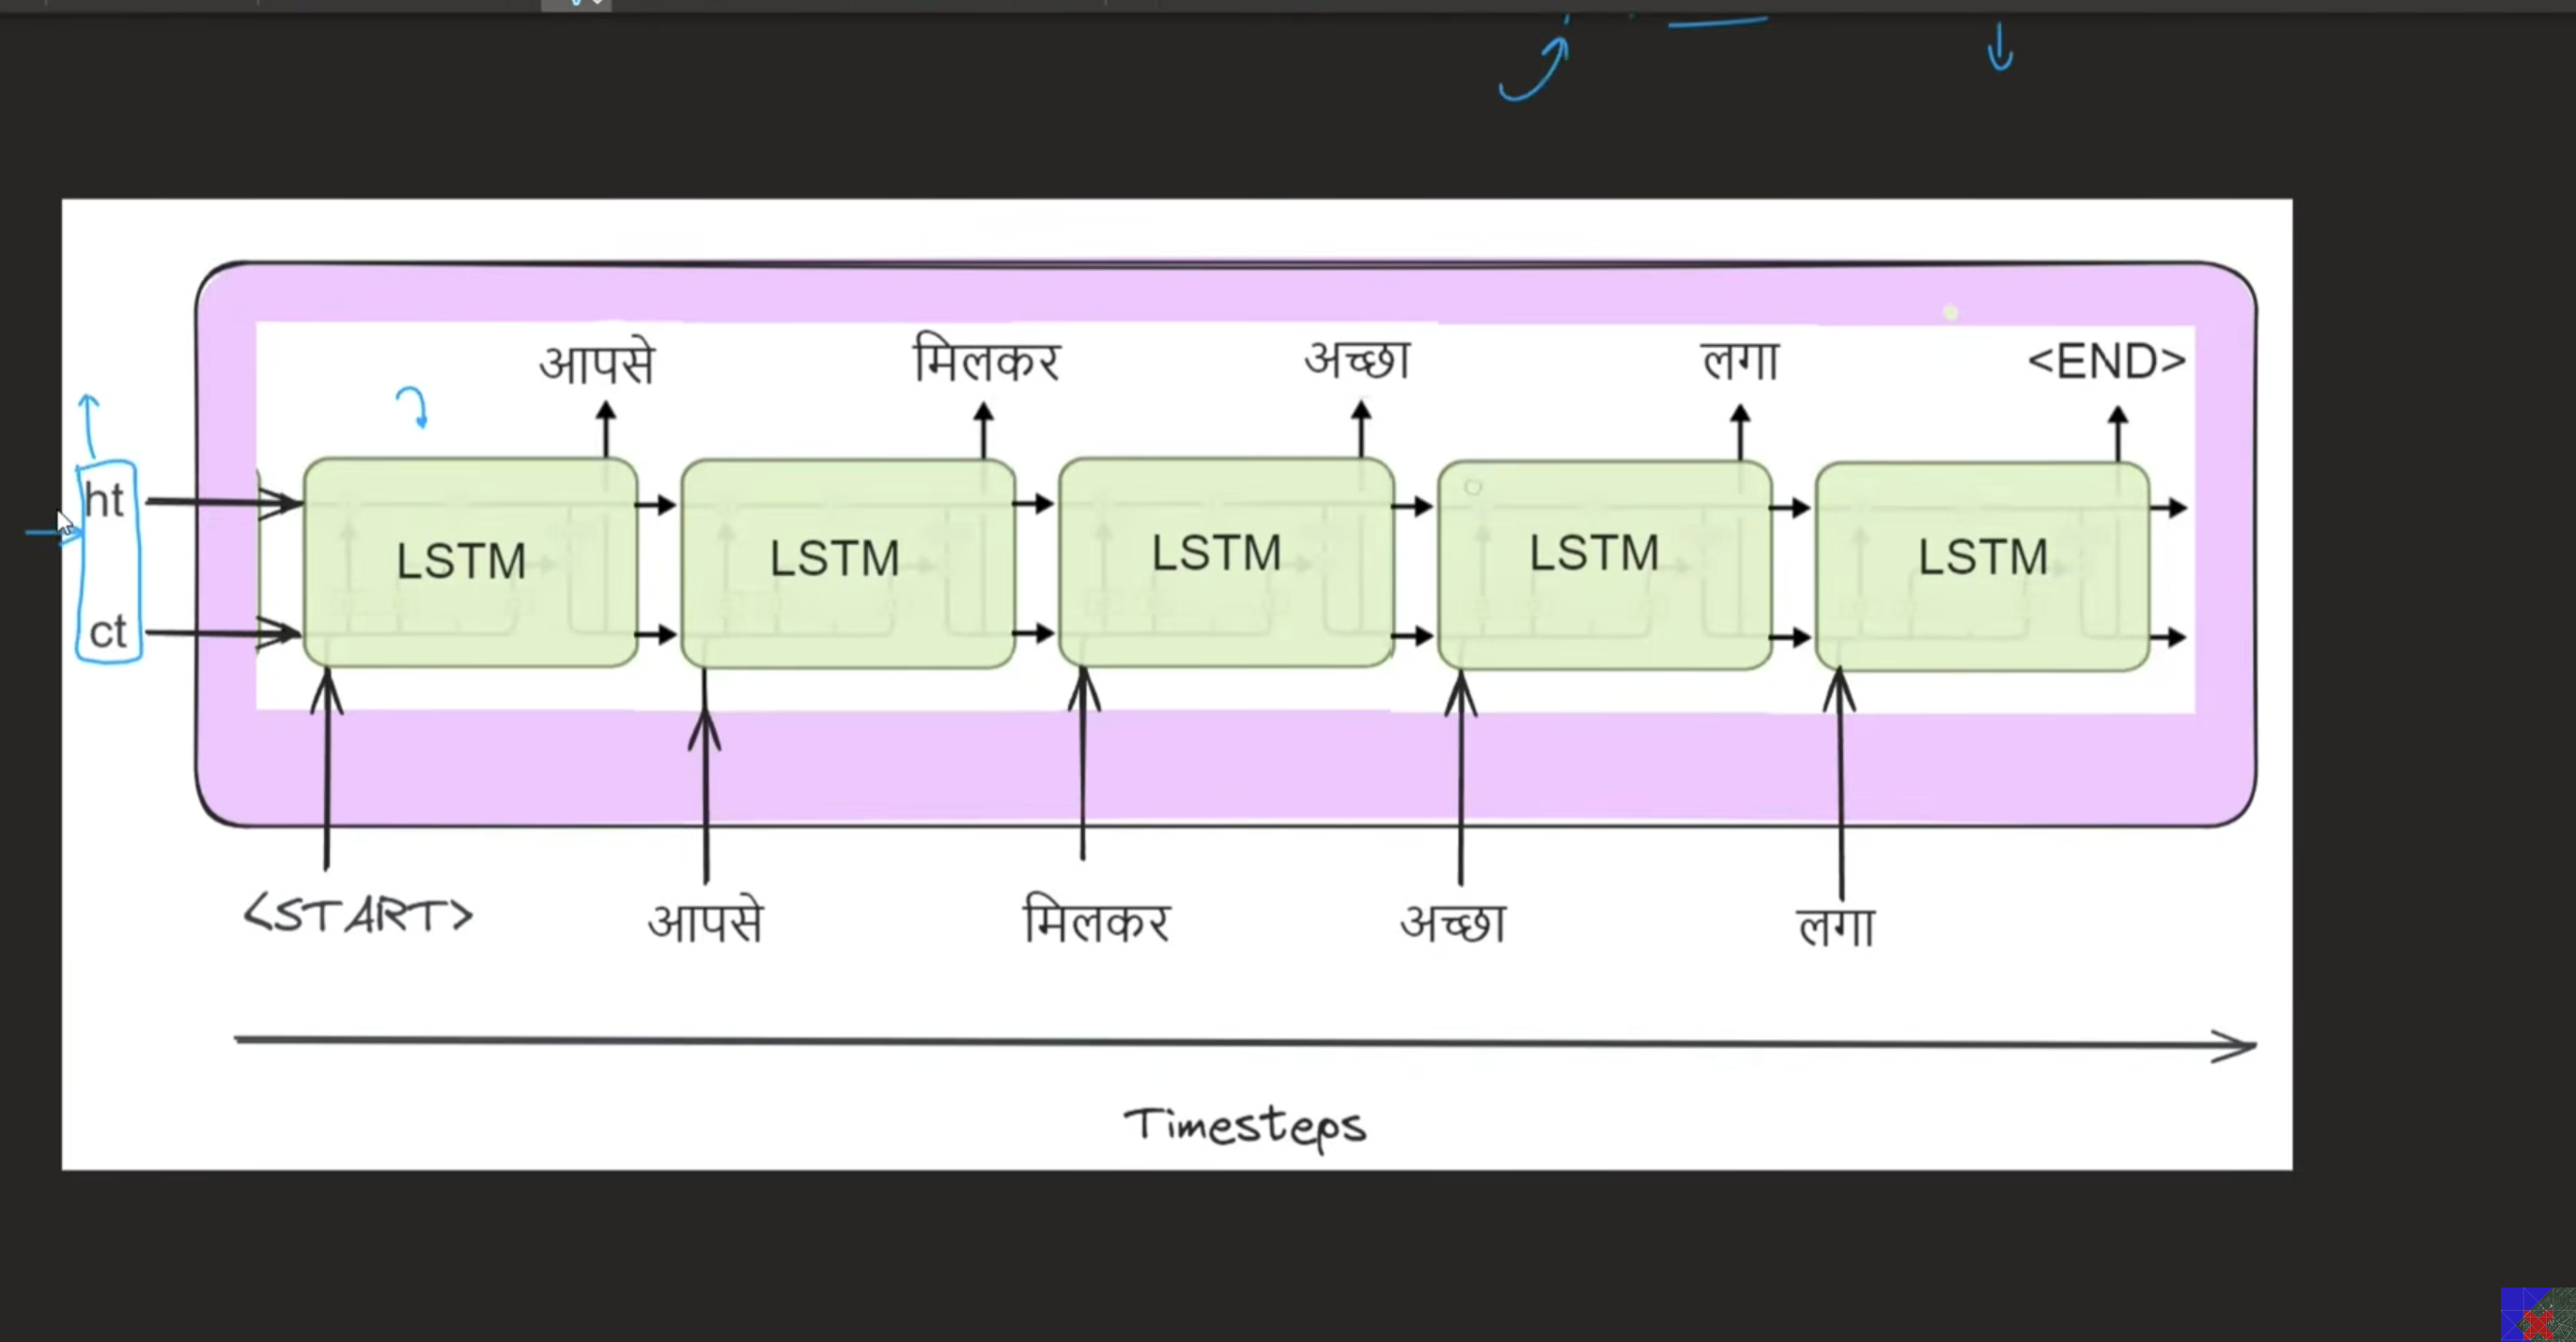
---

## 1. Introduction

Now that we understand the high-level overview, let's look inside the "black boxes." Both the encoder and decoder are built using **LSTM cells** (or GRUs). The encoder uses an LSTM to process the input sequence, while the decoder uses a **separate** LSTM to generate the output. This section explains how each works internally and how they connect.

---

## 2. Detailed Explanation

### The Encoder Internals

The encoder is essentially an **LSTM unfolded over time**.

```
                    ENCODER (LSTM Unrolled)
                    
    Time step:     t=1          t=2          t=3          t=4
                    │            │            │            │
    Input:        "nice"       "to"        "meet"       "you"
                    │            │            │            │
                    ▼            ▼            ▼            ▼
    ┌──────────┐  ┌──────────┐ ┌──────────┐ ┌──────────┐ ┌──────────┐
    │          │  │          │ │          │ │          │ │          │
    │ LSTM     │──│ LSTM     │─│ LSTM     │─│ LSTM     │ │ FINAL    │
    │ Cell 1   │  │ Cell 2   │ │ Cell 3   │ │ Cell 4   │ │ STATES   │
    │          │  │          │ │          │ │          │ │          │
    └──────────┘  └──────────┘ └──────────┘ └──────────┘ └──────────┘
                    │            │            │            │
    Hidden states:  h₁,c₁       h₂,c₂        h₃,c₃       h₄,c₄ ──▶ Context
                    │            │            │            │      Vector
    Initial:        h₀,c₀       (passed)     (passed)     (passed)
    (random)        │            │            │            │
                    └────────────┴────────────┴────────────┘
                              States propagate forward
```

**Step-by-Step Process:**

| Step | What Happens | Detail |
|------|--------------|--------|
| **Initialize** | Start with random h₀ and c₀ | Hidden state and cell state initial values |
| **t=1** | Feed "nice" (as vector) + h₀, c₀ | LSTM produces h₁, c₁ and some output (ignored) |
| **t=2** | Feed "to" + h₁, c₁ | LSTM produces h₂, c₂ |
| **t=3** | Feed "meet" + h₂, c₂ | LSTM produces h₃, c₃ |
| **t=4** | Feed "you" + h₃, c₃ | LSTM produces h₄, c₄ |
| **Final** | h₄ and c₄ become the **context vector** | These are passed to the decoder |

**Key Point:** The encoder's intermediate outputs are **discarded** — only the final hidden states matter.

---

### The Decoder Internals

The decoder is also an LSTM, but with a crucial difference: **its initial states are set to the encoder's final states**.

```
                    DECODER (LSTM Unrolled)
                    
    Context Vector: h₄, c₄ from encoder ─────────────────────┐
                                                             │
                                                             ▼
    Time step:     t=1          t=2          t=3          t=4
                    │            │            │            │
    Input:       <start>      "soch"       "lo"        <end>
                    │            │            │            │
                    ▼            ▼            ▼            ▼
    ┌──────────┐  ┌──────────┐ ┌──────────┐ ┌──────────┐
    │          │  │          │ │          │ │          │
    │ LSTM     │──│ LSTM     │─│ LSTM     │─│ LSTM     │
    │ Cell 1   │  │ Cell 2   │ │ Cell 3   │ │ Cell 4   │
    │          │  │          │ │          │ │          │
    └──────────┘  └──────────┘ └──────────┘ └──────────┘
                    │            │            │            │
    Initial:        h₄,c₄       h₁,c₁       h₂,c₂        h₃,c₃
    from encoder    (from       (from       (from        (from
                    encoder)    previous)   previous)    previous)
                    │            │            │            │
    Output:        "soch"       "lo"        <end>        (stop)
                    │            │            │
                    └────────────┴────────────┘
                        Next input = previous output
```

**Step-by-Step Process:**

| Step | What Happens | Detail |
|------|--------------|--------|
| **Initialize** | Set initial h, c = encoder's final h₄, c₄ | This gives decoder the context |
| **t=1** | Feed `<start>` token + h₄, c₄ | LSTM generates output → "soch" |
| **t=2** | Feed "soch" (previous output) + h₁, c₁ | LSTM generates output → "lo" |
| **t=3** | Feed "lo" (previous output) + h₂, c₂ | LSTM generates output → `<end>` |
| **Stop** | `<end>` detected | Decoder stops generating |

**Crucial Difference from Encoder:**
- Encoder's input is **the original source sentence** (known in advance)
- Decoder's input at each step is **its own previous output** (generated on the fly)

---

## 3. Key Points

| Component | Core LSTM | Initial States | Input | Output |
|-----------|-----------|----------------|-------|--------|
| **Encoder** | LSTM | Random (h₀, c₀) | Source words | Final states → Context Vector |
| **Decoder** | LSTM | Encoder's final states | Previous output + start token | Target words (one per step) |

- **Encoder and decoder are two different LSTMs** — they do NOT share weights
- Encoder processes the entire input **before** decoder starts generating
- Context vector = encoder's final hidden states (h<sub>t</sub>, c<sub>t</sub>)
- Decoder uses **auto-regression**: feeds its own output as next input
- Output stops when `<end>` token is generated

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Approach |
|---------|----------------|------------------|
| Thinking encoder and decoder use the same LSTM | They have different parameters | They are two independent LSTMs |
| Ignoring the cell state (cₜ) | Both hₜ and cₜ are needed | Context vector includes BOTH h and c |
| Expecting decoder to know output length | It generates until `<end>` | Stop condition is the `<end>` token |
| Feeding all source words to decoder at once | Decoder only gets the context vector | Only the summary (context) is passed |

---

## 5. Interview/Exam Questions

**Q1: What are the initial states of the encoder and decoder?**
> **Answer:** The encoder starts with random initial states (h₀ and c₀). The decoder starts with the encoder's **final** states as its initial states — this is how the context is transferred.

**Q2: Why do we need two separate LSTMs instead of reusing the same one?**
> **Answer:** The encoder and decoder have different roles — one "reads" and the other "writes." They process different types of data (source vs. target language) and need different learned parameters to perform their respective tasks effectively.

**Q3: What exactly is passed from encoder to decoder as the context vector?**
> **Answer:** The final hidden state (hₜ) and cell state (cₜ) from the last time step of the encoder. Both are passed to the decoder as its initial states.

**Q4: How does the decoder's input differ from the encoder's input?**
> **Answer:** The encoder receives the source sentence words in sequence (all known in advance). The decoder receives its own previous output at each step, starting with a special `<start>` token — it has no prior knowledge of what it will generate.

---

## 6. Revision Notes

- Encoder: **LSTM** with random start → processes input → outputs context (h,c)
- Decoder: **Separate LSTM** with encoder's final states → generates word-by-word
- Context vector = **h<sub>final</sub> + c<sub>final</sub>**
- Decoder is **auto-regressive**: output becomes next input
- `<start>` triggers generation; `<end>` stops it
- No fixed output length — decoder stops when it chooses to

---



# Topic 4: Training the Encoder-Decoder Architecture
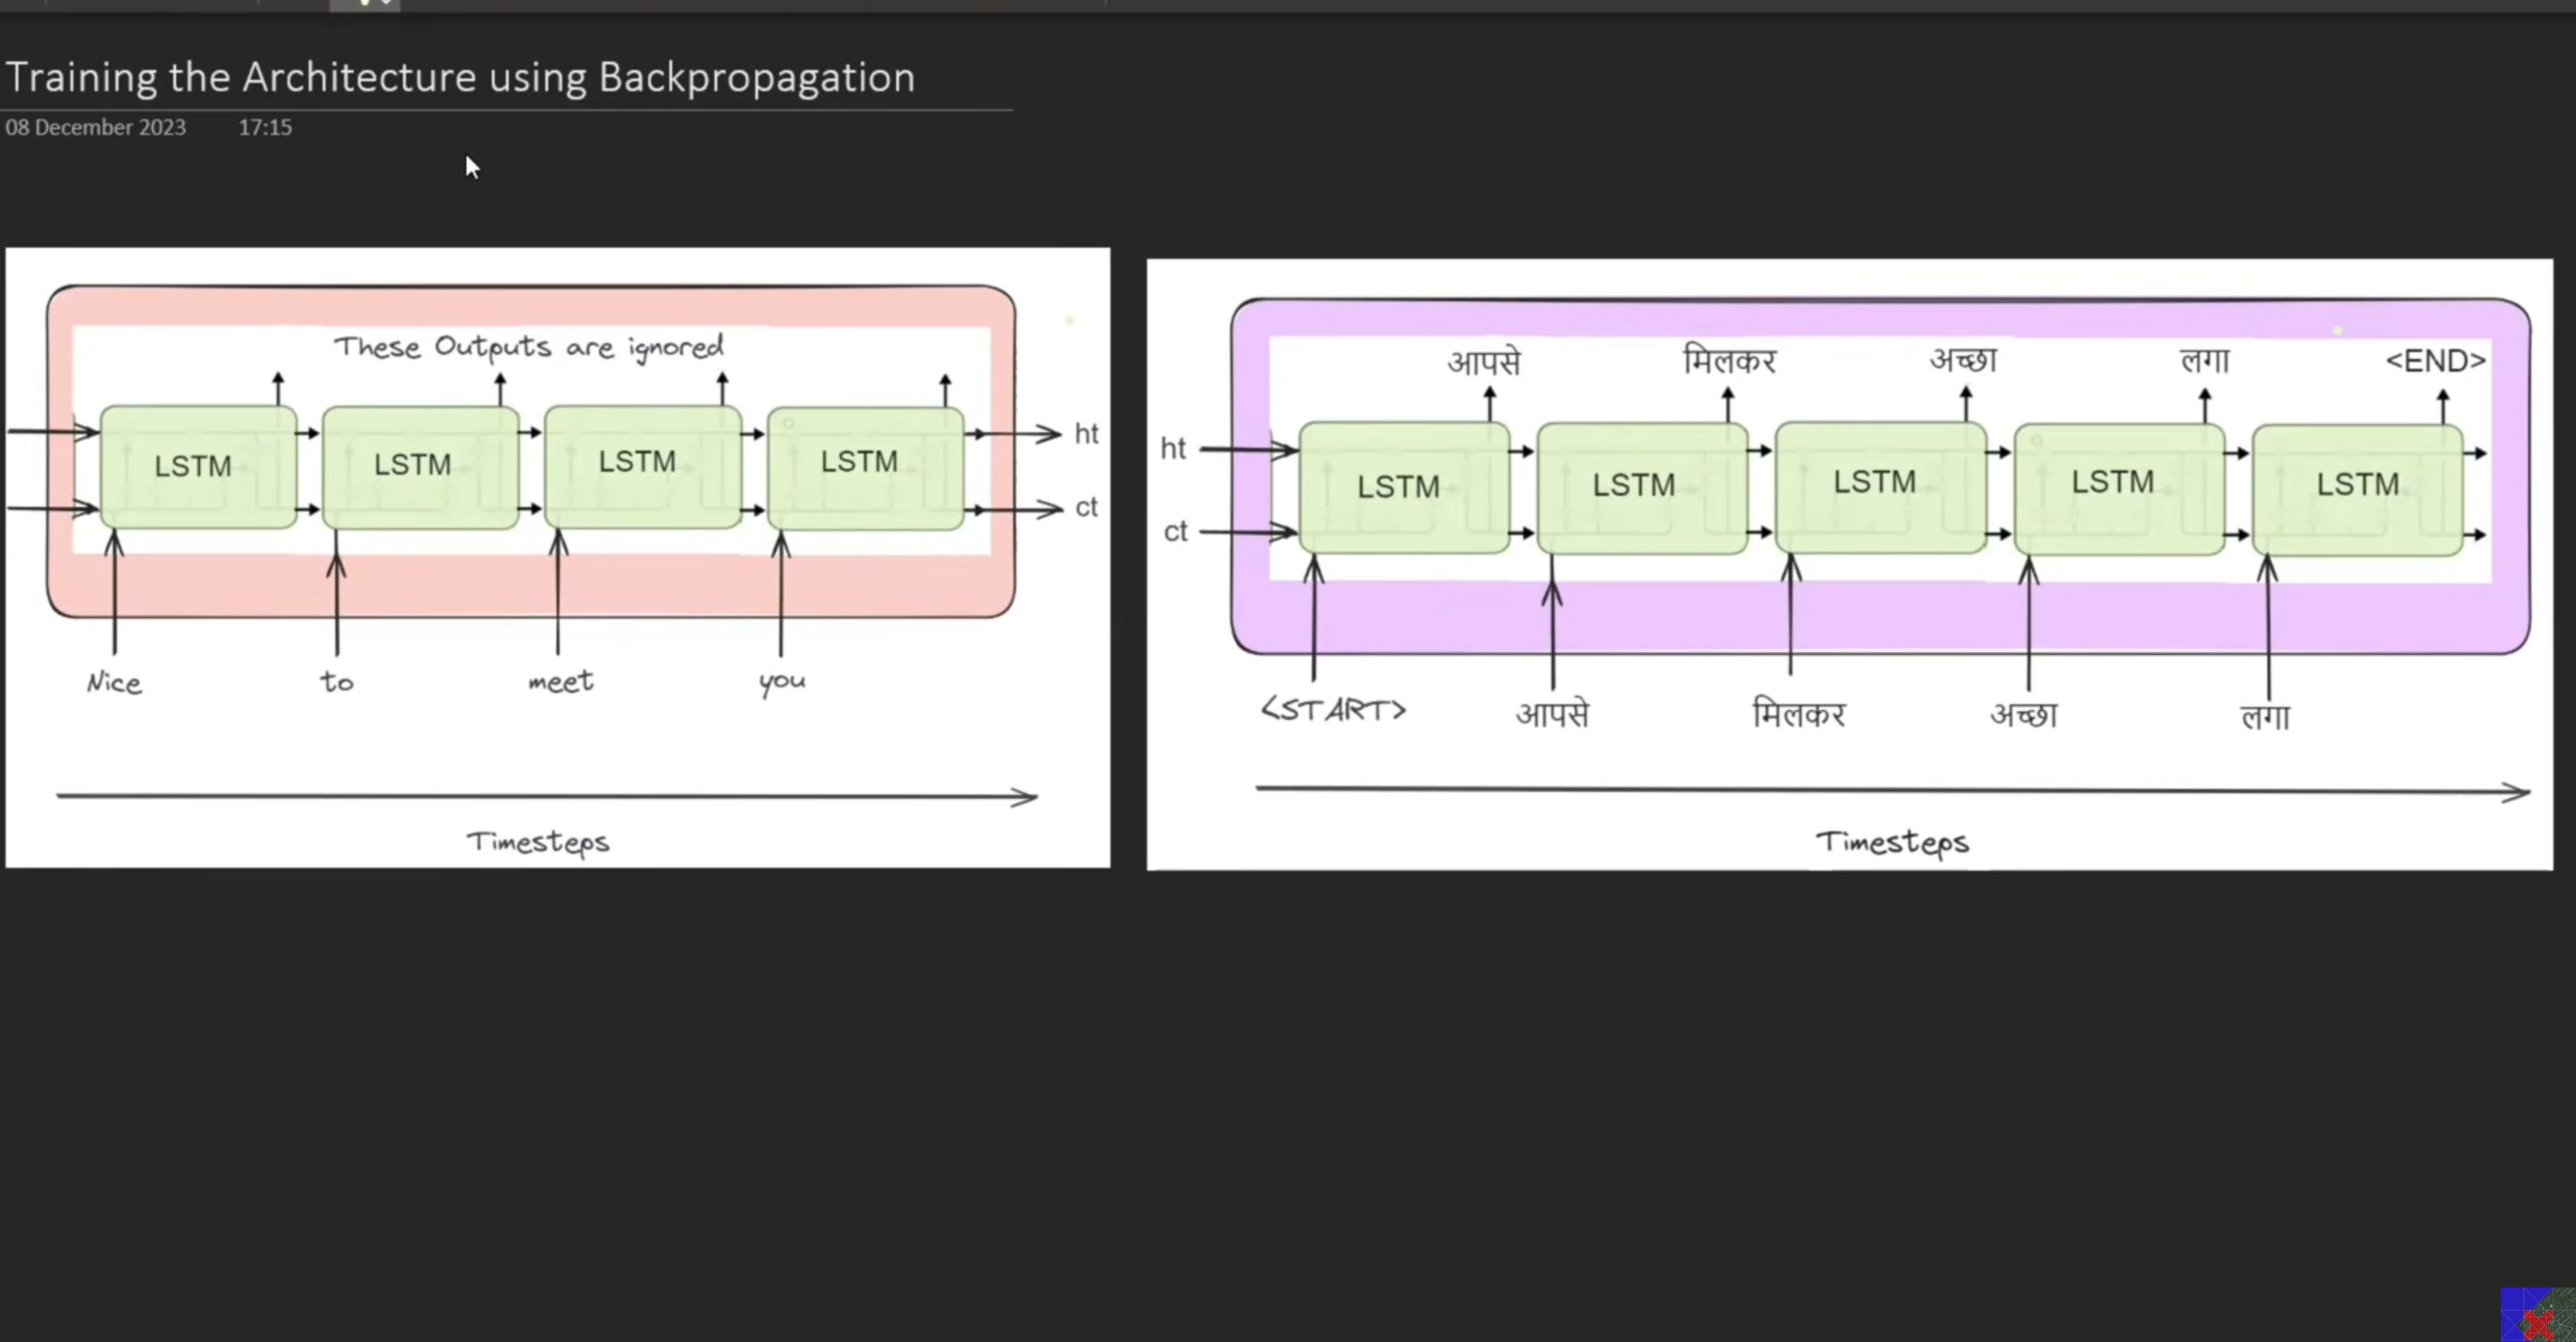
---

## 1. Introduction

Training an encoder-decoder is a **supervised learning** task. We need a dataset of input-output pairs (e.g., English-Hindi sentence pairs). The entire model — both encoder and decoder — is trained **together** using backpropagation through time. This section explains the complete training pipeline, from data preparation to weight updates.

---

## 2. Detailed Explanation

### 2.1 The Dataset: Parallel Data
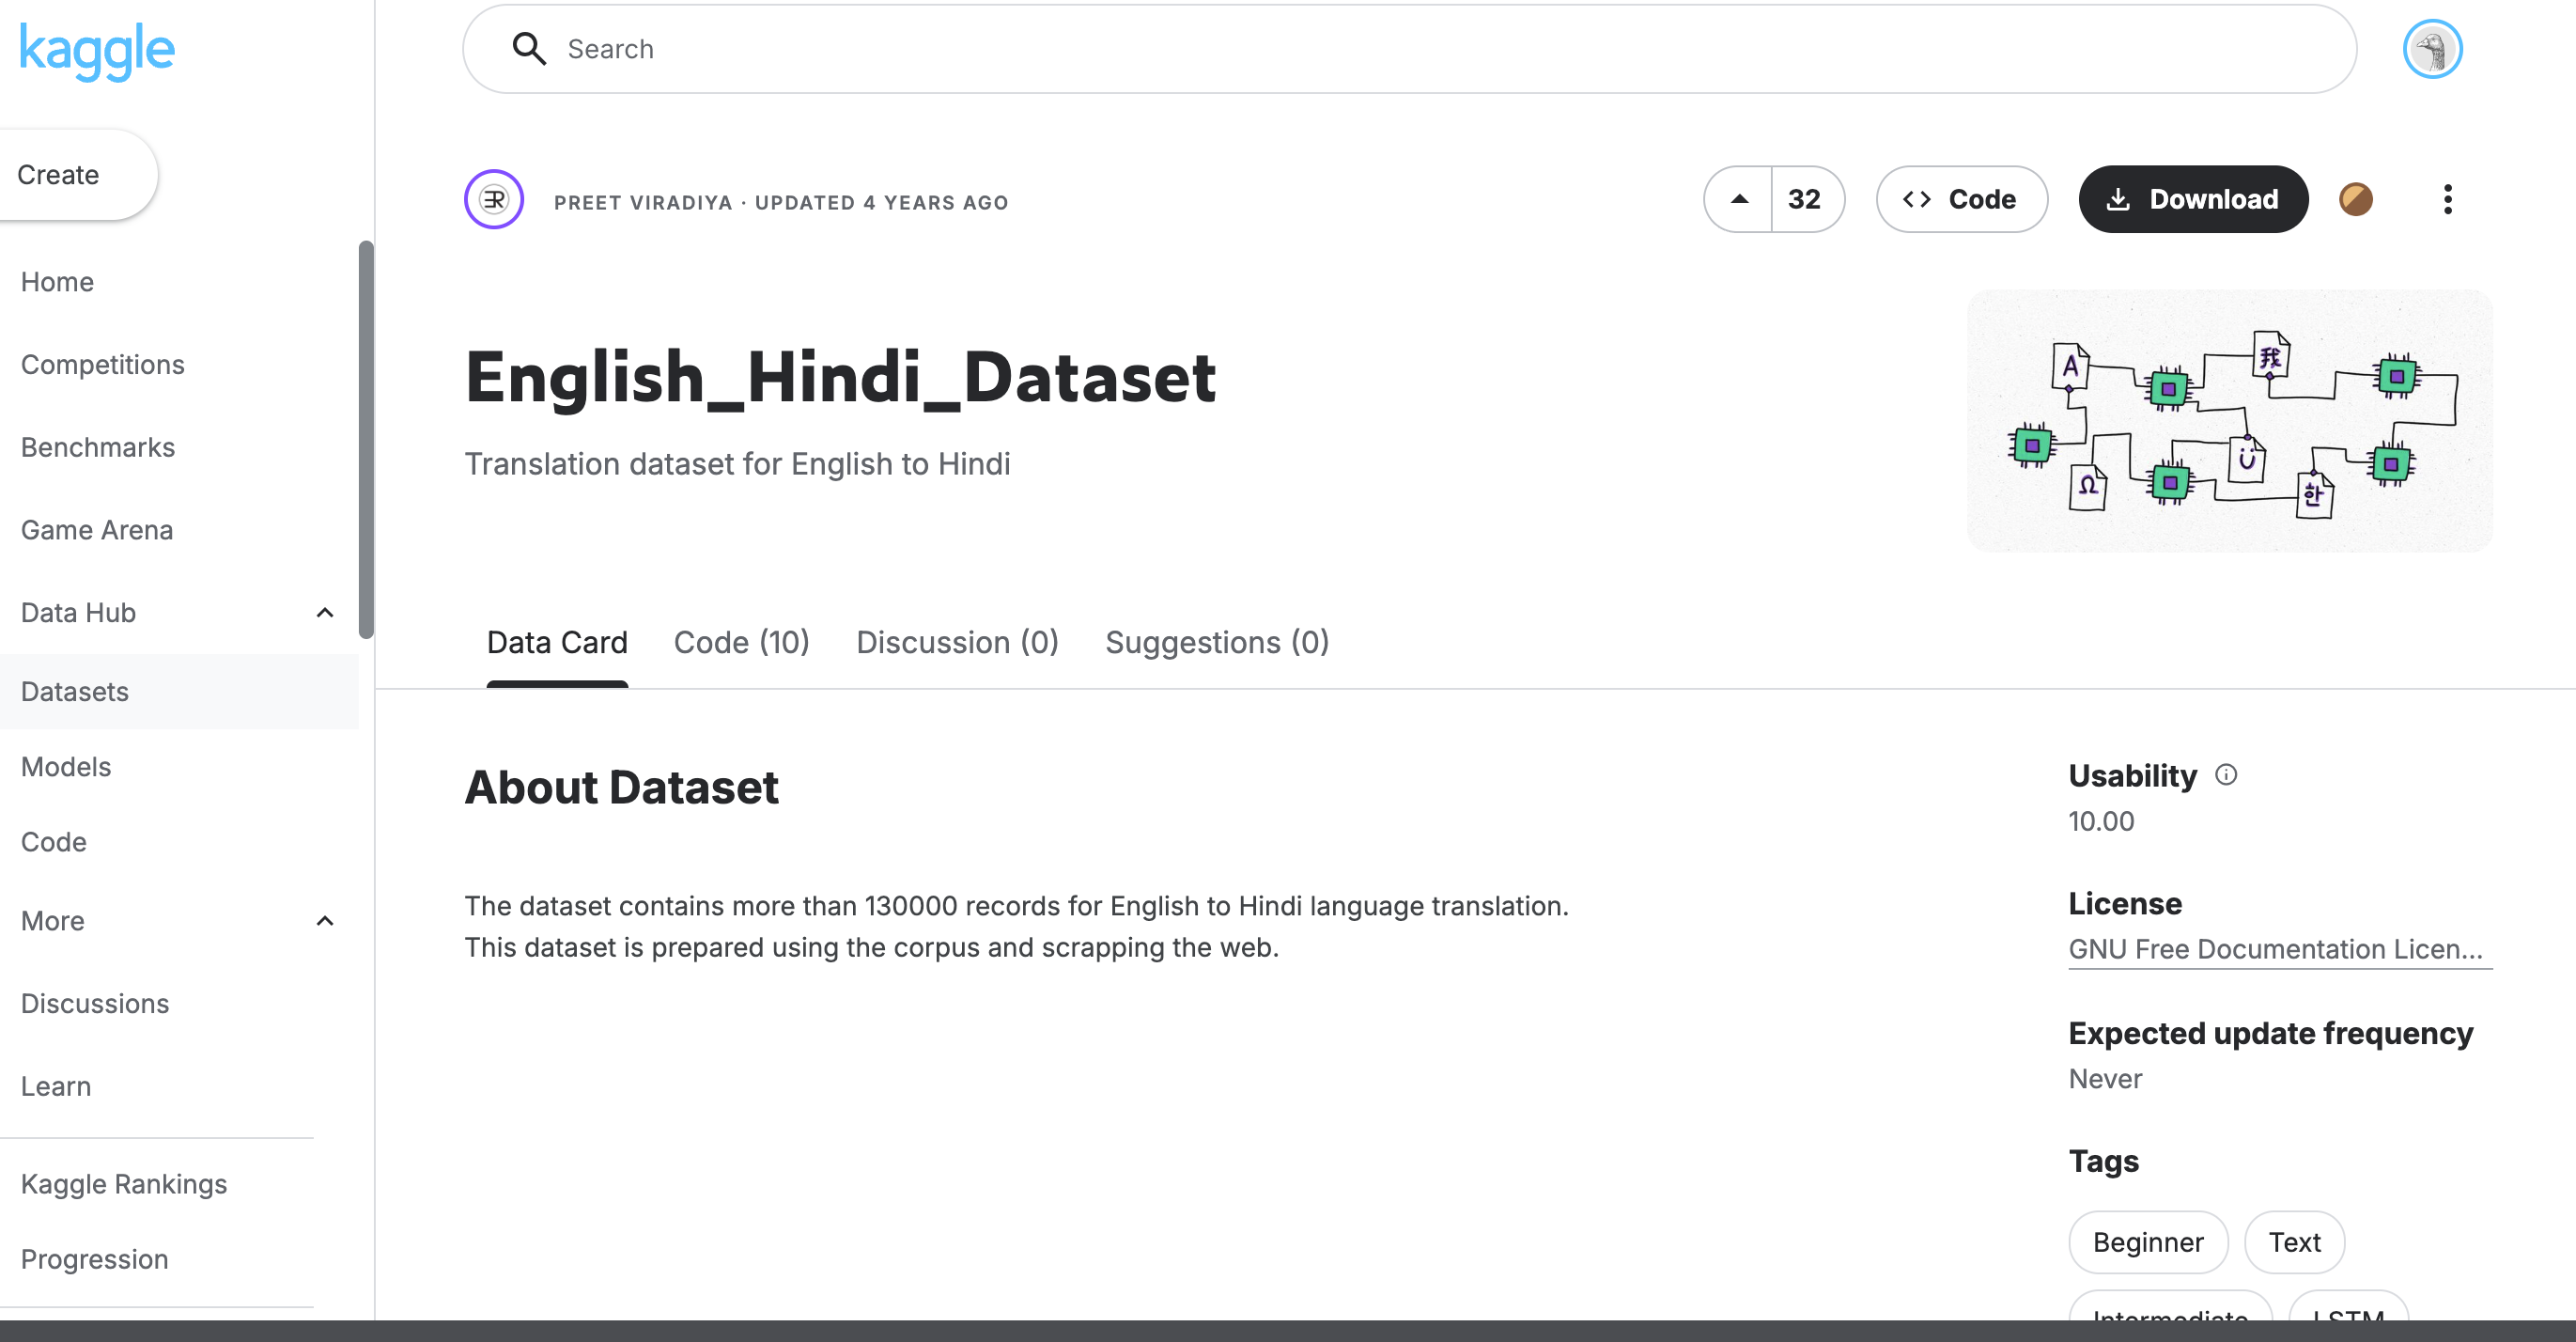
For machine translation, we use **parallel datasets**:

| English (Source) | Hindi (Target) |
|------------------|----------------|
| jump | कूदना |
| hello | नमस्ते |
| think about it | सोच लो |
| come in | अंदर आओ |

- This is **supervised learning** — we have both inputs and correct outputs
- Datasets can be huge (e.g., millions of sentences)
- Need to convert text to numbers before training

---

### 2.2 Data Preparation: Tokenization and One-Hot Encoding

**Step 1: Tokenization**

Split sentences into individual tokens (words):

| English Sentence | Tokens |
|------------------|--------|
| "think about it" | ["think", "about", "it"] |
| "come in" | ["come", "in"] |

| Hindi Sentence | Tokens |
|----------------|--------|
| "सोच लो" | ["सोच", "लो"] |
| "अंदर आओ" | ["अंदर", "आओ"] |

**Step 2: Build Vocabulary**

| English Vocabulary | Index | Hindi Vocabulary | Index |
|--------------------|-------|------------------|-------|
| think | 1 | `<start>` | 1 |
| about | 2 | `<end>` | 2 |
| it | 3 | सोच | 3 |
| come | 4 | लो | 4 |
| in | 5 | अंदर | 5 |
| | | आओ | 6 |
| | | (plus special tokens) | 7 |

**Note:** Hindi vocabulary includes `<start>` and `<end>` tokens because the decoder needs them.

**Step 3: One-Hot Encoding**

Each word becomes a vector of size = vocabulary size, with a single 1 at the word's index:

```
English Vocabulary: [think, about, it, come, in]
                    
"think" = [1, 0, 0, 0, 0]
"about" = [0, 1, 0, 0, 0]
"it"    = [0, 0, 1, 0, 0]
"come"  = [0, 0, 0, 1, 0]
"in"    = [0, 0, 0, 0, 1]
```

---

### 2.3 The Training Process: Step-by-Step

We'll use a toy dataset with just 2 examples:

| Example | Input (English) | Target (Hindi) |
|---------|-----------------|----------------|
| 1 | think about it | सोच लो |
| 2 | come in | अंदर आओ |

**Forward Propagation**

```
            Example 1: "think about it" → "सोच लो"
            
            ENCODER (with random weights)
            ┌─────────────────────────────────────────┐
            │                                         │
            │  t=1: input="think" → h₁,c₁            │
            │  t=2: input="about" → h₂,c₂            │
            │  t=3: input="it"    → h₃,c₃ (FINAL)   │
            │                                         │
            └─────────────────────────────────────────┘
                              │
                              ▼
                    Context Vector = h₃, c₃
                              │
                              ▼
            DECODER (with separate random weights)
            ┌─────────────────────────────────────────┐
            │                                         │
            │  t=1: input=<start> + context → output  │
            │       → "लो" (WRONG - should be "सोच") │
            │                                         │
            │  t=2: input="सोच" (teacher forcing)    │
            │       + states → output "आओ" (WRONG)   │
            │                                         │
            │  t=3: input="लो" (teacher forcing)     │
            │       + states → output <end> (CORRECT)│
            │                                         │
            └─────────────────────────────────────────┘
```

---

### 2.4 Teacher Forcing

**The Problem:**
At t=1, the decoder predicted "लो" instead of the correct "सोच". If we fed "लो" as input to t=2, the error would compound — training would be slow and unstable.

**The Solution: Teacher Forcing**

> During training, **always feed the correct output** from the dataset as the next input, regardless of what the model predicted.

```
Without Teacher Forcing (BAD):
t=1: predicted "लो" → feed "लो" to t=2 → error propagates → slow learning

With Teacher Forcing (GOOD):
t=1: predicted "लो" (ignore this)
t=2: feed "सोच" (correct from data) → model learns from correct context
t=3: feed "लो" (correct from data) → model learns from correct context
```

**Benefits of Teacher Forcing:**
- Faster convergence
- More stable training
- Prevents error accumulation during training

**Trade-off:** The model learns to predict based on correct inputs, not its own predictions — this is called **exposure bias** (handled later with scheduled sampling in advanced models).

---

### 2.5 Calculating the Loss

At each decoder time step, we have:
- **y_true**: The correct word (from dataset)
- **y_pred**: The model's prediction (from softmax)

**Loss Function: Cross-Entropy Loss**

For multi-class classification (choose 1 word out of V vocabulary words):

```
Loss = -Σ(y_trueᵢ × log(y_predᵢ))

Where y_true has 1 at the correct word's position and 0 elsewhere
```

**Example Calculation:**

| Time Step | y_true (one-hot) | y_pred (probabilities) | Loss |
|-----------|------------------|------------------------|------|
| t=1 | [1,0,0,0,0,0,0] | [0.2, 0.15, 0.15, 0.3, 0.1, 0.05, 0.05] | -log(0.2) = 1.61 |
| t=2 | [0,0,0,1,0,0,0] | [0.1, 0.2, 0.15, 0.1, 0.25, 0.15, 0.05] | -log(0.1) = 2.30 |
| t=3 | [0,1,0,0,0,0,0] | [0.05, 0.4, 0.2, 0.1, 0.1, 0.1, 0.05] | -log(0.4) = 0.92 |

**Total Loss = 1.61 + 2.30 + 0.92 = 4.83** (or average = 1.61)

**Observation:** When prediction is correct (t=3: y_true=0,1,0..., y_pred had 0.4 at that position), loss is **lower**. When prediction is wrong (t=1, t=2), loss is **higher**.

---

### 2.6 Backpropagation

Once loss is calculated, we perform backpropagation:

**Step 1: Calculate Gradients**
- Compute gradient of loss with respect to **every trainable parameter**:
  - LSTM weights (encoder and decoder)
  - Dense layer weights
  - Softmax layer parameters

**Step 2: Update Weights**
- Use an optimizer like **Adam** or **SGD**
- Each parameter is updated in the direction that **reduces loss**
- Update magnitude controlled by **learning rate**

```
new_weight = old_weight - learning_rate × gradient
```

---

### 2.7 The Complete Training Loop

```
For each epoch (pass through entire dataset):
    For each training example (source, target):
        1. Forward propagation:
           - Encode source sentence → context vector
           - Decode with teacher forcing → predictions
        
        2. Calculate loss (cross-entropy)
        
        3. Backpropagation:
           - Compute gradients
           - Update all weights using optimizer
        
        4. Repeat for next example
```

**For our 2-example dataset:**
1. Train on "think about it" → update weights
2. Train on "come in" → update weights again
3. Repeat for multiple epochs until loss converges

After enough training, the model learns to translate correctly.

---

## 3. Key Points

| Concept | Explanation |
|---------|-------------|
| **Parallel Dataset** | Source-target sentence pairs for supervised learning |
| **Tokenization** | Split sentences into individual words/tokens |
| **One-Hot Encoding** | Convert words to vectors (size = vocabulary size) |
| **Teacher Forcing** | Feed correct target words as decoder input during training |
| **Cross-Entropy Loss** | Measures difference between predicted and true distributions |
| **Backpropagation** | Calculate gradients and update weights |
| **Optimizer** | Algorithm that updates weights (Adam, SGD) |
| **Learning Rate** | Controls update step size |

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Approach |
|---------|----------------|------------------|
| Not including `<start>` and `<end>` in vocabulary | Decoder needs these special tokens | Always include special tokens in target vocabulary |
| Not using teacher forcing during training | Model learns from its own errors → slow/unstable | Feed correct outputs at each step during training |
| Training encoder and decoder separately | They need to work together | Train them **end-to-end** simultaneously |
| Using one-hot for large vocabularies | Inefficient (millions of dimensions) | Use embeddings (next topic) |
| Forgetting to calculate loss at each time step | Model only learns final output | Calculate loss at EVERY decoder time step |

---

## 5. Interview/Exam Questions

**Q1: What is teacher forcing and why is it used?**
> **Answer:** Teacher forcing is a training technique where we feed the correct target word as the next input to the decoder, regardless of what the model predicted. It's used to speed up convergence, stabilize training, and prevent error accumulation.

**Q2: What loss function is used in training and why?**
> **Answer:** Cross-entropy loss is used because at each time step, the decoder performs multi-class classification (choosing 1 word out of V possible words). Cross-entropy measures the difference between the predicted probability distribution and the true distribution (one-hot).

**Q3: How are gradients calculated and used?**
> **Answer:** Gradients are calculated via backpropagation through time — we compute the derivative of the loss with respect to every trainable parameter. These gradients indicate how much each parameter contributed to the error and in which direction to adjust them to reduce loss. An optimizer then updates the weights using these gradients and a learning rate.

**Q4: Why is the dataset called "parallel"?**
> **Answer:** It's called parallel because each source sentence has a corresponding target sentence aligned with it — they're "parallel" examples in two languages. This is necessary for supervised learning since we need to compute loss by comparing predictions against correct targets.

---

## 6. Revision Notes

- Training uses **supervised learning** with parallel datasets
- **Tokenization** → **One-hot encoding** → **Training**
- **Teacher forcing** feeds correct outputs during training
- **Cross-entropy loss** calculated at each decoder step
- **Backpropagation** updates all weights (encoder + decoder)
- **Optimizer + Learning rate** control weight updates
- Training happens **end-to-end** (both encoder and decoder together)

---


# Topic 5: Prediction (Inference) and How It Differs from Training

---

## 1. Introduction

Once training is complete, we have a fully trained encoder-decoder model with optimized weights. Now we want to use it to translate **new sentences** we've never seen before. This process is called **prediction** or **inference**. Inference is fundamentally different from training — there is **no teacher forcing**, no loss calculation, and no backpropagation.

---

## 2. Detailed Explanation

### 2.1 The Core Difference: Teacher Forcing vs. Auto-Regression

| Aspect | Training | Inference (Prediction) |
|--------|----------|------------------------|
| **Decoder input** | Correct target word from dataset (teacher forcing) | Model's own previous prediction |
| **Loss calculation** | Yes (to update weights) | No |
| **Backpropagation** | Yes | No |
| **Weights** | Updated after each batch | Frozen (unchanged) |
| **Knowledge of output** | We know the correct translation | We DON'T know the correct translation |
| **Process** | Uses correct context | Uses self-generated context |

---

### 2.2 Prediction Process: Step-by-Step

Let's translate "think about it" using our trained model:

```
                    PHASE 1: ENCODING (SAME AS TRAINING)
                    
    Input: "think about it" (new sentence, but same as training example)
    
    ┌─────────────────────────────────────────────────────────────┐
    │                                                             │
    │  t=1: "think" → one-hot → LSTM_encoder → h₁, c₁          │
    │  t=2: "about" → one-hot → LSTM_encoder → h₂, c₂          │
    │  t=3: "it"    → one-hot → LSTM_encoder → h₃, c₃ (FINAL) │
    │                                                             │
    └─────────────────────────────────────────────────────────────┘
                              │
                              ▼
                    Context Vector = h₃, c₃
                              │
                              ▼
                    PHASE 2: DECODING (DIFFERENT FROM TRAINING!)
                    ┌─────────────────────────────────────────────┐
                    │                                             │
                    │  t=1: input = <start> + context            │
                    │        ↓                                    │
                    │        LSTM_decoder → softmax              │
                    │        ↓                                    │
                    │        Predicted probabilities             │
                    │        ↓                                    │
                    │        Choose word with HIGHEST probability│
                    │        → "सोच" ✓ (correct this time)      │
                    │                                             │
                    │  t=2: input = "सोच" (model's own output)   │
                    │        + updated states                     │
                    │        ↓                                    │
                    │        LSTM_decoder → softmax              │
                    │        ↓                                    │
                    │        Choose word with HIGHEST probability│
                    │        → "लो" ✓ (correct this time)       │
                    │                                             │
                    │  t=3: input = "लो" (model's own output)    │
                    │        + updated states                     │
                    │        ↓                                    │
                    │        LSTM_decoder → softmax              │
                    │        ↓                                    │
                    │        Choose word with HIGHEST probability│
                    │        → <end> → STOP!                     │
                    │                                             │
                    └─────────────────────────────────────────────┘
                    
                    Final Output: "सोच लो"
```

---

### 2.3 The Softmax Layer and Word Selection

At each decoder time step, the LSTM output passes through a **softmax layer**:

```
Input to softmax: A vector of numbers (logits) from LSTM
                  ↓
         Softmax function
                  ↓
    Probability distribution over vocabulary
    (each word gets a probability between 0 and 1, sum = 1)
                  ↓
    ┌──────────────────────────────────────────────┐
    │ Word        │ Probability  │ Chosen?         │
    │─────────────│──────────────│─────────────────│
    │ <start>     │ 0.01         │                 │
    │ <end>       │ 0.02         │                 │
    │ सोच         │ 0.35         │ ←─── HIGHEST!   │
    │ लो          │ 0.25         │                 │
    │ अंदर        │ 0.15         │                 │
    │ आओ          │ 0.12         │                 │
    │ ...         │ ...          │                 │
    └──────────────────────────────────────────────┘
                  ↓
    Output word = "सोच" (the word with highest probability)
```

**Selection Method: Greedy Decoding**
- Simply choose the word with the highest probability at each step
- Fast and simple, but may not always produce the best translation

---

### 2.4 What If the Model Makes a Mistake?

During inference, we **cannot correct** the model's mistakes — there's no teacher forcing because we don't know the correct output.

```
                    EXAMPLE: WRONG PREDICTION
                    
    t=1: predicted "लो" (should be "सोच")
         ↓
    t=2: input = "लो" (model's wrong prediction)
         ↓
    t=2: predicted "आओ" (now completely off track)
         ↓
    t=3: predicted <end>
         ↓
    Final Output: "लो आओ" (WRONG translation!)
```

**Why This Happens:**
- The model was trained with teacher forcing (always received correct inputs)
- During inference, it relies on its own predictions
- Once an error occurs, it compounds (like a snowball effect)

**Solutions (covered in advanced topics):**
- Beam search (keep multiple candidate translations)
- Scheduled sampling (gradually reduce teacher forcing during training)

---

### 2.5 Summary: Training vs. Inference Comparison

| Aspect | Training | Inference |
|--------|----------|-----------|
| **Weights** | Being updated | Frozen |
| **Encoder input** | Source sentence (known) | Source sentence (known) |
| **Decoder input** | Correct target word (from dataset) | Previous output word (self-generated) |
| **Input at t=1** | `<start>` | `<start>` |
| **Stopping condition** | Fixed sequence length | Generating `<end>` token |
| **Loss calculation** | Yes (cross-entropy) | No |
| **Backpropagation** | Yes | No |
| **Teacher forcing** | Yes | No |
| **Word selection** | Compare with true label | Choose highest probability |
| **Error correction** | Possible (teacher forcing) | Impossible (no labels available) |

---

## 3. Key Points

- Inference uses **trained, frozen weights** — no learning happens
- Decoder receives its **own previous output** as input (no teacher forcing)
- At each step, choose the word with **highest softmax probability**
- Process continues until `<end>` token is generated
- Mistakes **compound** because the model uses its own wrong predictions
- Greedy decoding (pick highest probability) is simple but can be suboptimal

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Approach |
|---------|----------------|------------------|
| Using teacher forcing during inference | We don't have correct labels | Feed model's own predictions |
| Not stopping when `<end>` appears | Model will generate forever | Check for `<end>` at every step |
| Still calculating loss during inference | No labels to compare against | Just generate output, no loss |
| Updating weights during inference | Model is already trained | Keep weights frozen |
| Expecting same performance as training | Training had perfect context | Inference is harder — errors can compound |

---

## 5. Interview/Exam Questions

**Q1: Why can't we use teacher forcing during inference?**
> **Answer:** Teacher forcing requires knowing the correct output at each time step to feed as next input. During inference, we don't know the correct translation — we're trying to produce it. We have no labels to guide the model, so it must rely on its own predictions.

**Q2: What happens if the model makes an error early during inference?**
> **Answer:** The error propagates because the wrong word becomes the input for the next time step. This can lead to completely wrong translations — like a snowball effect. This is called **error accumulation** or **exposure bias**.

**Q3: How does the model know when to stop generating?**
> **Answer:** The decoder has a special `<end>` token in its vocabulary. When the model predicts `<end>` with the highest probability, we stop generating output. Without this, the decoder would continue indefinitely.

**Q4: What is greedy decoding and what are its limitations?**
> **Answer:** Greedy decoding means choosing the word with the highest probability at each time step. It's simple and fast, but can be suboptimal because it doesn't consider alternative sequences that might have higher overall probability. Advanced methods like beam search explore multiple candidates.

---

## 6. Revision Notes

- **Inference**: Model predicts on new data with **frozen weights**
- **No teacher forcing**: Feed model's own predictions as next input
- **Stopping**: Stop when `<end>` is generated
- **Word selection**: Choose highest softmax probability (greedy decoding)
- **Errors compound** during inference
- Training ≠ Inference (different input feeding mechanism)

---



# Topic 6: Three Key Improvements (Embeddings, Deep LSTM, Reversing Input)

---

## 1. Introduction

The basic encoder-decoder architecture works, but it has limitations. The original paper introduced three key improvements to significantly boost performance: **(1) using embeddings instead of one-hot encoding**, **(2) stacking multiple LSTM layers (Deep LSTM)**, and **(3) reversing the input sequence**. These improvements made the architecture practical for real-world translation tasks.

---

## 2. Detailed Explanation

### Improvement 1: Using Embeddings Instead of One-Hot Encoding
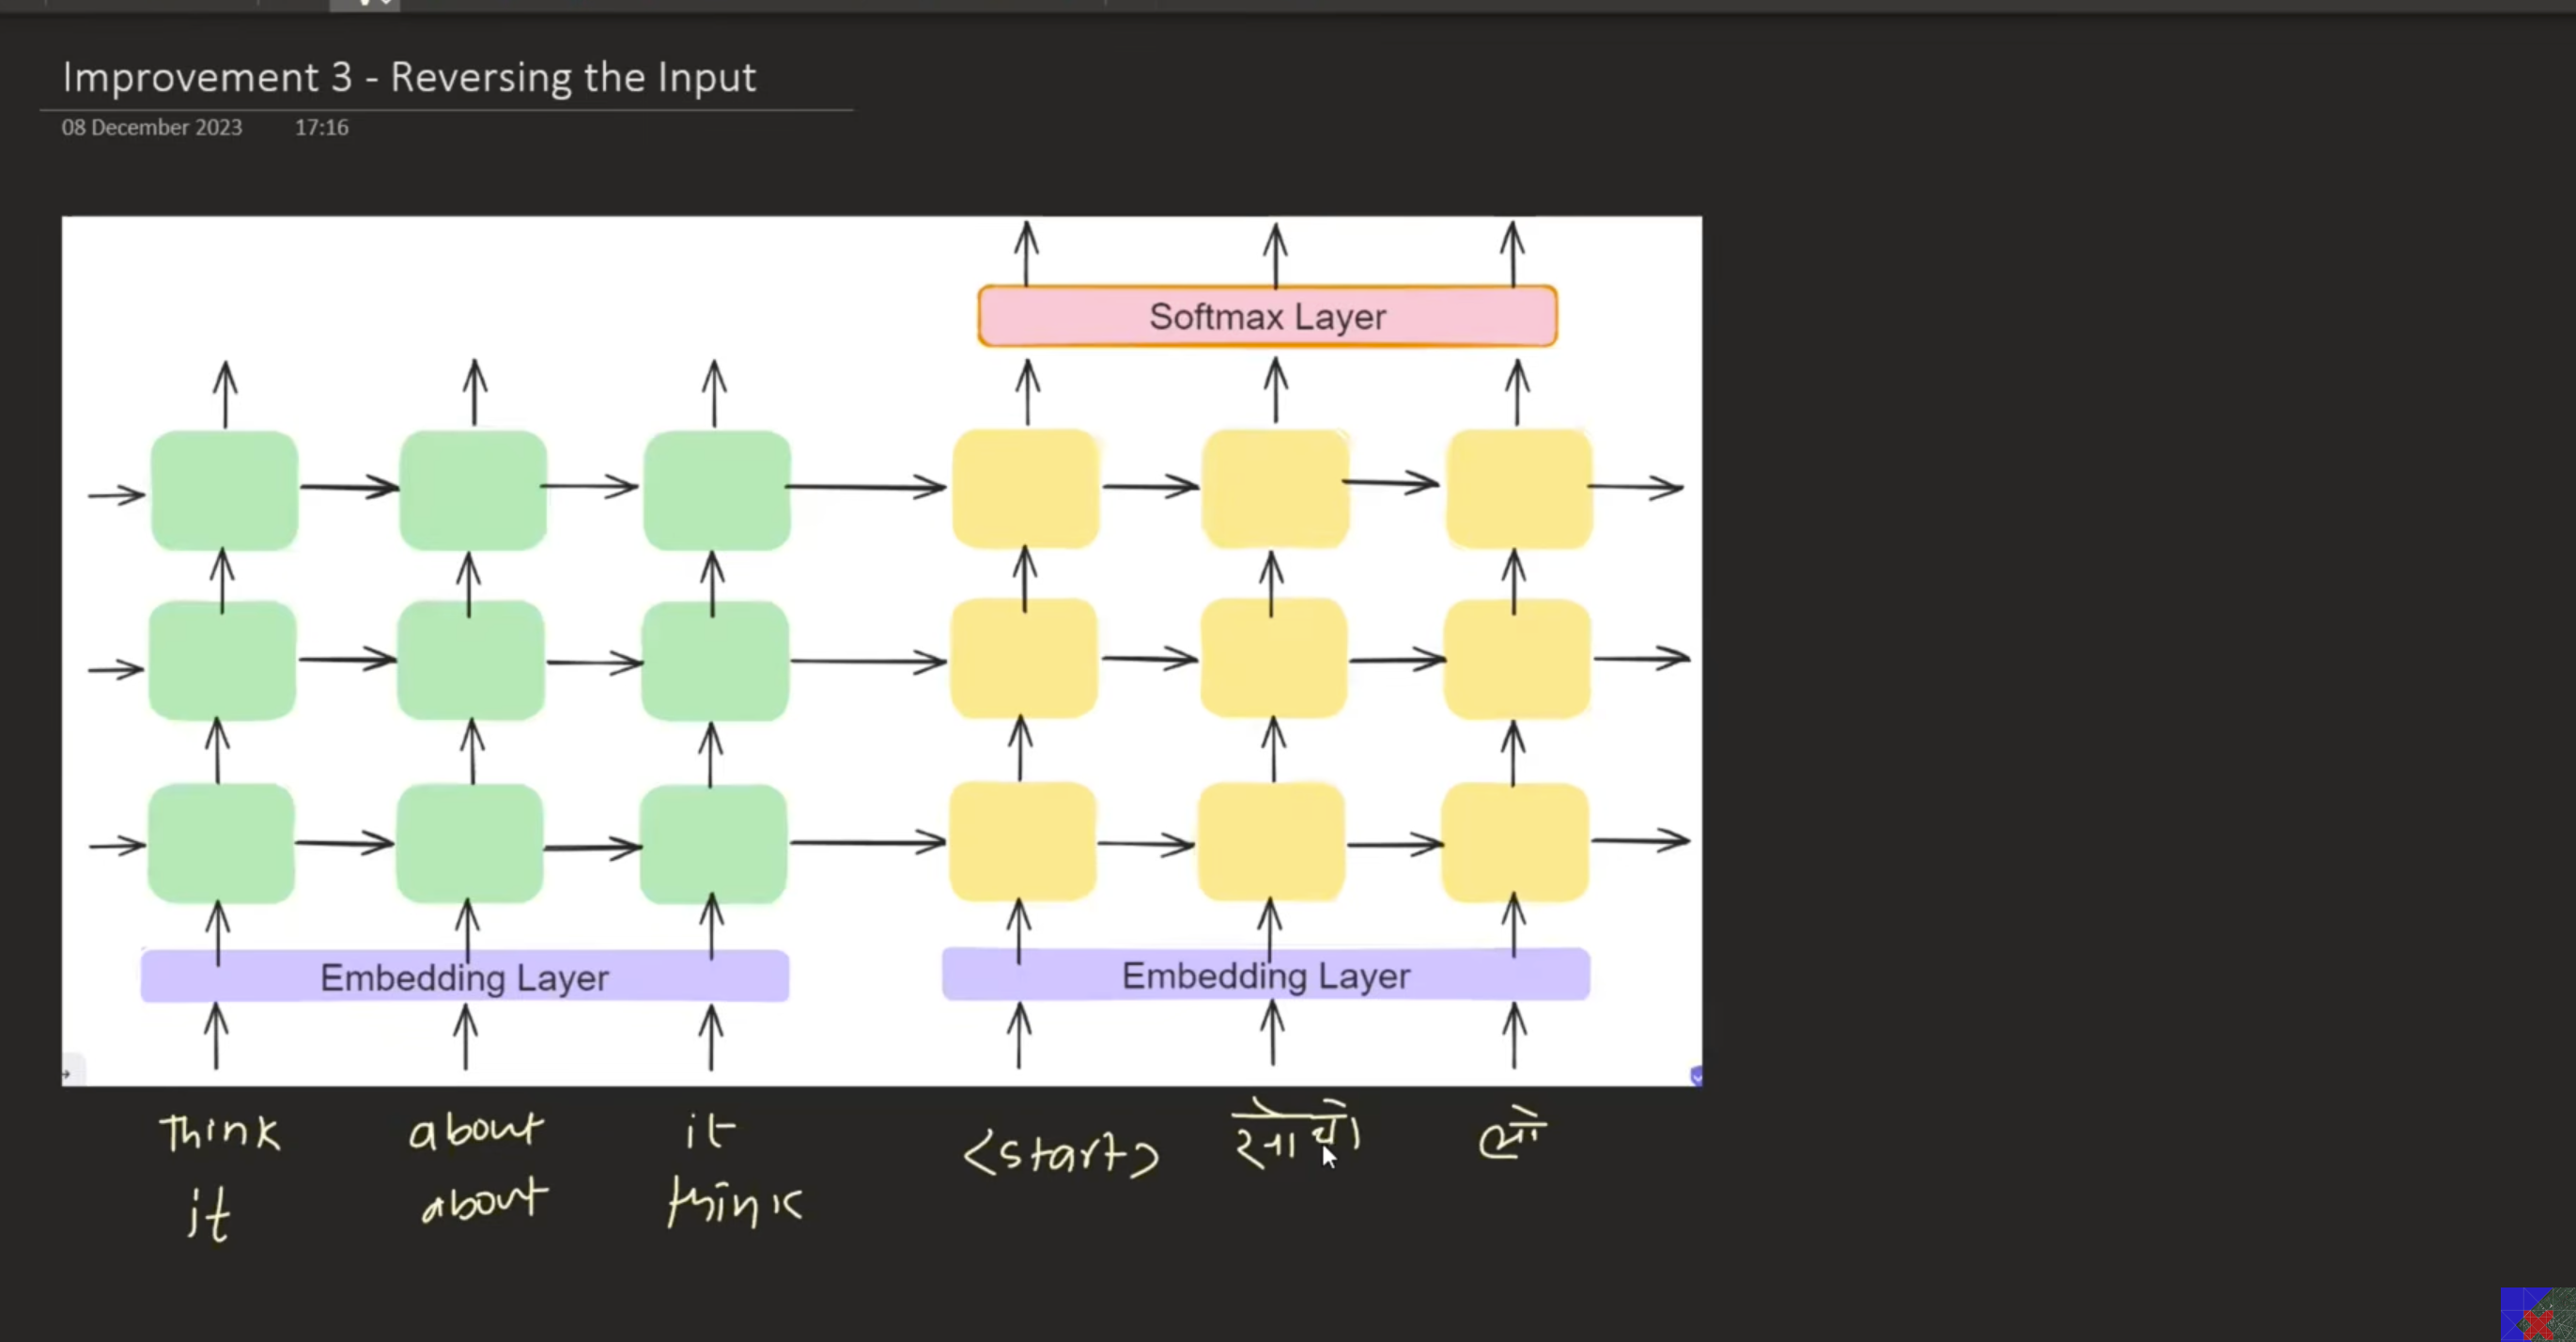
**The Problem with One-Hot Encoding:**

| Issue | Explanation |
|-------|-------------|
| **High Dimensionality** | If vocabulary has 1,000,000 words, each vector is 1,000,000-dimensional |
| **Sparse** | Most values are zero (only one 1, rest zeros) — wasteful |
| **No Semantic Meaning** | "king" and "queen" have completely different vectors (no relationship captured) |
| **Computational Cost** | Huge vectors = slow training, large memory usage |

**The Solution: Embeddings**

Embeddings are **dense, low-dimensional vector representations** of words.

```
One-Hot Encoding:     [0, 0, 1, 0, 0, 0, 0, ...]  (1,000,000 dimensions)
                      ↑                          ↑
                    Only one 1         All zeros (wasted space)

Embedding:            [0.23, -0.45, 0.67]         (Only 3 dimensions!)
                      Dense vector (no zeros)
                      Captures semantic meaning
```

**How Embeddings Work:**

```
        "think"                          [0.23, -0.45, 0.67]
           │                                    │
           ▼                                    ▼
    ┌─────────────┐                   ┌─────────────────────┐
    │  Embedding  │                   │  Similar words have │
    │   Layer     │                   │  similar vectors    │
    └─────────────┘                   │                     │
           │                          │  "think" ≈ "consider"│
           ▼                          │  "king" - "man" +   │
    3D vector output                  │  "woman" ≈ "queen"  │
                                      └─────────────────────┘
```

**Benefits of Embeddings:**

| Benefit | Explanation |
|---------|-------------|
| **Low-dimensional** | Typically 50-1000 dimensions vs. 1,000,000+ |
| **Dense** | All values are meaningful (no zeros) |
| **Captures Semantics** | Similar words have similar vectors |
| **Learned from Data** | Can be trained on your specific dataset |
| **Transfer Learning** | Can use pre-trained embeddings (Word2Vec, GloVe) |

**Applying Embeddings to Encoder-Decoder:**

```
                    BASIC ARCHITECTURE (Before)
                    ┌─────────────────────────────────┐
                    │  "think" → One-hot (5D) → LSTM  │
                    └─────────────────────────────────┘
                    
                    IMPROVED ARCHITECTURE (After)
                    ┌─────────────────────────────────┐
                    │  "think" → Embedding (3D) → LSTM│
                    │            ↑                    │
                    │         Learned or              │
                    │         Pre-trained             │
                    └─────────────────────────────────┘
```

**Practical Implementation:**
1. Add an embedding layer **before** the encoder LSTM
2. Add an embedding layer **before** the decoder LSTM
3. Either use pre-trained embeddings (Word2Vec, GloVe) or train from scratch
4. Embedding weights are **trainable** (updated during backpropagation)

---

### Improvement 2: Using Deep LSTM (Multiple Layers)
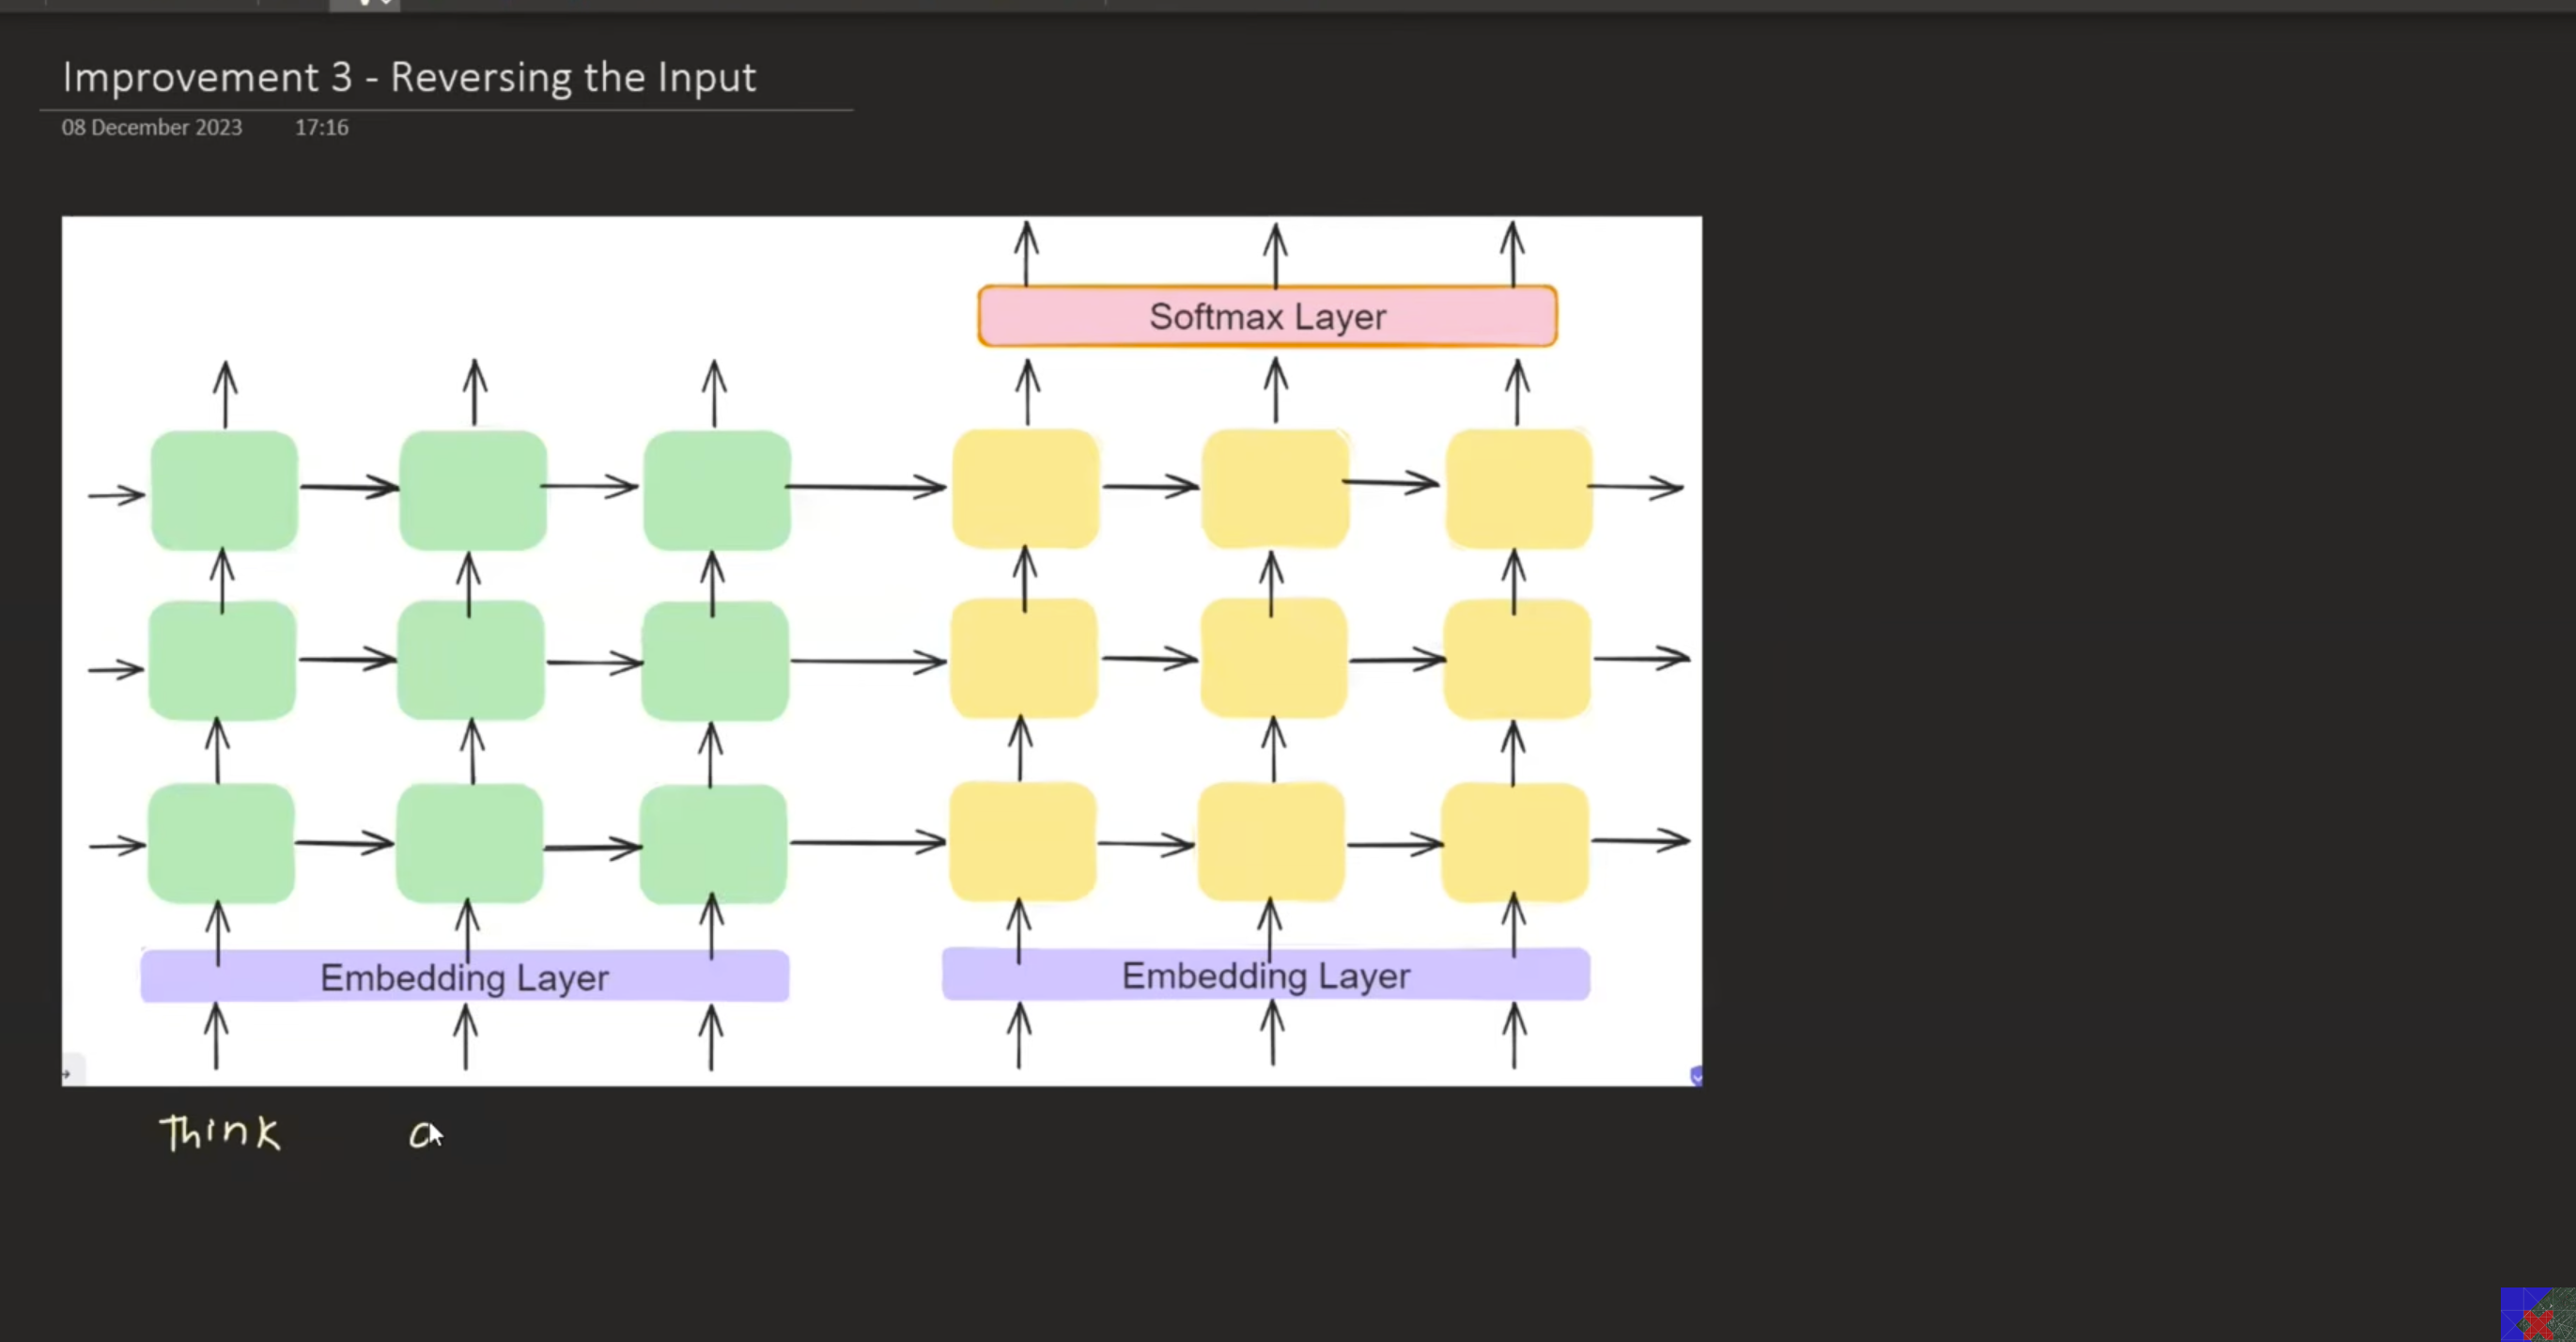
**The Problem with Single-Layer LSTM:**

| Issue | Explanation |
|-------|-------------|
| **Limited Capacity** | One layer has limited ability to capture complex patterns |
| **Poor on Long Sentences** | Struggles with long paragraphs or complex translations |
| **Limited Hierarchical Understanding** | Cannot capture word-level, phrase-level, and sentence-level meaning separately |

**The Solution: Stack Multiple LSTM Layers (Deep LSTM)**

```
                    SINGLE LAYER LSTM                          DEEP LSTM (3 Layers)
    ┌──────────────────────────────────┐          ┌─────────────────────────────────────┐
    │                                  │          │  Output     ┌──────────────┐          │
    │  Input ──▶ LSTM Layer 1 ──▶ Out │          │  ──────────▶│  Layer 3     │──────────│▶
    │                                  │          │             │  (Paragraph  │          │
    └──────────────────────────────────┘          │             │   Level)    │          │
                                                  │             └──────▲───────┘          │
                                                  │                    │                   │
                                                  │             ┌──────┴───────┐          │
                                                  │             │  Layer 2     │──────────│▶
                                                  │             │  (Sentence   │          │
                                                  │             │   Level)     │          │
                                                  │             └──────▲───────┘          │
                                                  │                    │                   │
                                                  │             ┌──────┴───────┐          │
                                                  │  Input ──▶ │  Layer 1     │──────────│▶
                                                  │             │  (Word       │          │
                                                  │             │   Level)     │          │
                                                  │             └──────────────┘          │
                                                  └─────────────────────────────────────┘
```

**How Deep LSTM Works (3 layers shown):**

| Layer | Role | What It Learns |
|-------|------|----------------|
| **Bottom Layer (Layer 1)** | Word-level understanding | Grammar, word order, singular/plural, verb forms |
| **Middle Layer (Layer 2)** | Sentence-level understanding | Meaning, intent, overall message |
| **Top Layer (Layer 3)** | Paragraph-level understanding | Broader context, discourse structure |

**Information Flow in Deep LSTM:**

```
For each time step:
    1. Input goes to bottom layer
    2. Bottom layer produces output → passes UP to middle layer
    3. Middle layer produces output → passes UP to top layer
    4. Top layer produces final output
    
    (States also propagate FORWARD in time at each layer)
```

**Three Key Benefits:**

| Benefit | Explanation |
|---------|-------------|
| **1. Better Long-Term Dependencies** | Multiple context vectors (one per layer) can store more information, making long sentence translation better |
| **2. Hierarchical Understanding** | Lower layers capture word-level features, middle layers capture sentence structure, top layers capture overall meaning |
| **3. Increased Model Capacity** | More parameters → can learn more complex patterns (provided sufficient data to avoid overfitting) |

**Original Paper Setup:**
- Used **4 layers** of LSTM
- Each layer had **1000 units** (dimensionality)
- Experimentally proven to outperform single-layer LSTM

---

### Improvement 3: Reversing the Input Sequence

**The Concept:**
Instead of feeding the source sentence in normal order, **reverse it** before passing to the encoder.

```
Normal Order:    "think about it" → [think] [about] [it]
                                    ↑       ↑       ↑
                                    t=1     t=2     t=3

Reversed Order:  "it about think" → [it] [about] [think]
                                    ↑       ↑       ↑
                                    t=1     t=2     t=3
```

**Why Does This Work?**

The key insight: **Shorter path for gradient propagation**

```
                    NORMAL ORDER (Long distance)
    Source:   "think" ←—— distance ——→ "about" ←—— distance ——→ "it"
                 │                                           │
                 │            (LONG DISTANCE)               │
                 │                                           │
    Target:     "सोच"     —— distance ——→     "लो"
                 ↑                                           ↑
                Large distance between corresponding words (hard for backprop)
    
    
                    REVERSED ORDER (Short distance)
    Source:   "it" ← distance → "about" ← distance → "think"
                 │                                     │
                 │        (SHORT DISTANCE)             │
                 │                                     │
    Target:     "लो"      —— distance ——→     "सोच"
                 ↑                                     ↑
               Small distance between corresponding words (easier for backprop)
```

**Why This Improves Performance:**

| Factor | Explanation |
|--------|-------------|
| **Better Gradient Flow** | Corresponding words are closer → gradients propagate more effectively |
| **Easier Initial Word Translation** | In English, initial words often carry more context; reversing makes them align with early decoder outputs |
| **Improved BLEU Score** | Original paper achieved significantly better translation quality with this trick |

**When Does This Work?**

| Works Well | Works Less Well |
|------------|-----------------|
| English → French (shown in paper) | Languages where final words carry more context |
| Languages where early words are more important | Languages with different word order structures |
| Translation tasks where alignment benefits | Tasks without clear source-target alignment |

**Important Caveat:**
> This trick **doesn't always work** — it's language-pair specific. It helped in the original English→French translation because early English words aligned better with French output when reversed. For other language pairs, test to see if it helps.

---

## 3. Key Points

| Improvement | Purpose | How It Works |
|-------------|---------|--------------|
| **Embeddings** | Replace sparse, high-dim one-hot vectors | Learn/sue dense, low-dim word representations |
| **Deep LSTM** | Improve capacity and hierarchical understanding | Stack multiple LSTM layers (2-4 layers) |
| **Reversing Input** | Improve gradient flow and alignment | Feed source sentences backwards to encoder |

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Approach |
|---------|----------------|------------------|
| Applying embeddings only to encoder | Decoder also needs embeddings | Use embeddings in BOTH encoder and decoder |
| Using embeddings without training them | They won't adapt to your data | Make embedding weights trainable (or fine-tune pre-trained) |
| Stacking too many LSTM layers | Overfitting, slow training | Start with 2-3 layers, add more only if data is large |
| Always reversing input | May hurt performance for some language pairs | Test it; it's not universally beneficial |
| Using one-hot for large vocabularies | Memory/performance issues | Use embeddings (dense, low-dimensional) |

---

## 5. Interview/Exam Questions

**Q1: What are the advantages of embeddings over one-hot encoding?**
> **Answer:** Embeddings are (1) low-dimensional, (2) dense (no zeros), (3) capture semantic meaning (similar words have similar vectors), and (4) can be learned from data or fine-tuned, making them much more efficient and effective than sparse one-hot vectors.

**Q2: Why does Deep LSTM perform better than single-layer LSTM?**
> **Answer:** Deep LSTM provides (1) more parameters to capture complex patterns, (2) hierarchical understanding (word→sentence→paragraph level), (3) better handling of long-term dependencies through multiple context vectors, and (4) the original paper demonstrated experimentally that 4-layer LSTM significantly outperformed single-layer LSTM.

**Q3: How does reversing the input help translation?**
> **Answer:** Reversing brings corresponding source and target words closer together, improving gradient flow during backpropagation. In English→French translation, it aligned early English words with early French outputs more naturally, making training easier and improving the BLEU score.

**Q4: Should we always reverse the input? Why or why not?**
> **Answer:** No. Reversing input works for specific language pairs where early words carry more contextual weight (like English→French). It may not help or may even hurt performance for other language pairs. Always test on your specific data.

---

## 6. Revision Notes

- **Improvement 1**: Replace one-hot with **embeddings** (dense, low-dim, semantic)
- **Improvement 2**: Use **Deep LSTM** (2-4 layers) for better capacity and hierarchy
- **Improvement 3**: **Reverse input sequence** to improve gradient flow (language-pair specific)
- Original paper used all three: embeddings + 4-layer Deep LSTM + reversed input
- These improvements made the architecture practical for real-world translation

---



# Topic 7: Original Paper Details and Final Summary

---

## 1. Introduction

We've covered the encoder-decoder architecture from the ground up — its components, training, inference, and key improvements. Now let's look at the **original research paper** by Ilya Sutskever, Oriol Vinyals, and Quoc V. Le (2014) that introduced this architecture. Understanding the paper's details helps connect theory to practice and shows how these ideas performed on real-world data.

---

## 2. Detailed Explanation

### 2.1 Paper Overview

| Aspect | Details |
|--------|---------|
| **Title** | Sequence to Sequence Learning with Neural Networks |
| **Authors** | Ilya Sutskever, Oriol Vinyals, Quoc V. Le (Google) |
| **Year** | 2014 |
| **Task** | Machine Translation (English → French) |
| **Key Contribution** | First successful use of pure neural networks for large-scale machine translation, surpassing statistical machine translation (SMT) baselines |

---

### 2.2 Dataset Specifications

**Large-Scale Parallel Dataset:**

| Metric | Value |
|--------|-------|
| **Total Sentences** | ~12 million |
| **English Words** | 304 million |
| **French Words** | 348 million |
| **Source** | WMT'14 English-to-French dataset (public) |

**Vocabulary Sizes:**

| Language | Vocabulary Size | Notes |
|----------|-----------------|-------|
| **English (Source)** | 160,000 words | Most frequent words in dataset |
| **French (Target)** | 80,000 words | Most frequent words in dataset |
| **Out-of-Vocabulary (OOV)** | Special `<UNK>` token | Words not in vocabulary replaced with `<UNK>` |

**Special Tokens Used:**
- `<EOS>` = End of Sentence (used instead of separate `<start>` and `<end>`)
- `<UNK>` = Unknown word (for words not in vocabulary)

---

### 2.3 Architecture Specifications Used in Paper

| Component | Specification |
|-----------|---------------|
| **Encoder** | 4-layer Deep LSTM |
| **Decoder** | 4-layer Deep LSTM (separate, different weights) |
| **LSTM Units per Layer** | 1,000 units each |
| **Embedding Dimension** | 3,000 (or 1,000 in some configurations) |
| **Input Embedding** | 1,000-dimensional word embeddings |
| **Output Layer** | Softmax over target vocabulary (80,000 words) |
| **Input Reversal** | Yes — input sequences were reversed |
| **Deep LSTM** | Yes — 4 layers stacked |
| **Source Vocabulary** | 160,000 words |
| **Target Vocabulary** | 80,000 words |

**Key Detail:**
```
Architecture:     Encoder (4 layers, 1000 units each)
                  ↓
                  Context Vector (from all 4 layers)
                  ↓
                  Decoder (4 layers, 1000 units each)
                  ↓
                  Softmax (80,000 output classes)

Total Parameters: ~384 million (state-of-the-art at that time)
```

---

### 2.4 Training Details

| Parameter | Value |
|-----------|-------|
| **Optimizer** | Stochastic Gradient Descent (SGD) |
| **Learning Rate** | 0.0001 (or decreasing schedule) |
| **Batch Size** | 128 sentences |
| **Initialization** | Random (uniform distribution) |
| **GPU Usage** | 8 GPUs (parallel training) |
| **Training Time** | ~10 days |
| **Gradient Clipping** | Used to prevent exploding gradients |

**Training Process:**
1. Each training example: (source English sentence, target French sentence)
2. Teacher forcing used during training
3. Loss calculated at each decoder time step (cross-entropy)
4. Gradients computed via backpropagation through time (BPTT)
5. Weights updated using SGD with momentum

---

### 2.5 Evaluation: BLEU Score

**What is BLEU Score?**
- **BLEU** (Bilingual Evaluation Understudy) is a metric for evaluating machine translation quality
- Compares machine-generated translation to human reference translations
- Higher BLEU = better translation quality (range: 0-100, typically 20-40 for good translations)

**Results from the Paper:**

| Model | BLEU Score |
|-------|------------|
| **Baseline (Statistical MT)** | ~33.3 |
| **Encoder-Decoder (Basic)** | ~32.0 |
| **Encoder-Decoder (with Improvements)** | **34.8** ✅ |
| **State-of-the-art at that time** | ~34.5 |

**Why This Was Significant:**
- First time a pure neural network **outperformed** the best statistical machine translation systems
- Demonstrated that deep learning could handle large-scale translation tasks
- Paved the way for future models (Attention, Transformers, LLMs)

---

### 2.6 Summary of Key Paper Contributions

| Contribution | Impact |
|--------------|--------|
| **Encoder-Decoder Architecture** | Novel neural architecture for variable-length sequence processing |
| **Deep LSTM (4 layers)** | Showed stacking layers improved performance |
| **Input Reversal** | Clever trick that improved BLEU score significantly |
| **Large-Scale Training** | Proved neural models could scale to millions of sentences |
| **Beating SMT Baseline** | First neural translation system to outperform statistical methods |
| **BLEU Score 34.8** | Set a new state-of-the-art benchmark |

---

## 3. Key Points

- Original paper by **Sutskever et al. (2014)** introduced encoder-decoder architecture
- Used **4-layer Deep LSTM** with **1,000 units per layer**
- Applied **input reversal** (English reversed) for better gradient flow
- Trained on **12 million** sentence pairs (English → French)
- Achieved **BLEU score 34.8** → beating the best statistical models
- This paper was a **landmark** in neural machine translation
- Today's architectures (Transformers, LLMs) evolved from this foundational work

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | Correct Understanding |
|---------|----------------|----------------------|
| Thinking the paper used GRU or RNN | They explicitly used LSTM | Paper used LSTM (4 layers) |
| Using `<start>` and `<end>` as separate tokens | Paper used only `<EOS>` | Paper used `<EOS>` for both starting and ending |
| Thinking embeddings were trained from scratch | Paper used pre-trained or random init | They used 1,000-dimensional embeddings (trained during training) |
| Assuming BLEU score above 50 is good | BLEU 34.8 was excellent for 2014 | BLEU 34.8 was state-of-the-art and surpassed SMT |
| Claiming this was the first Seq2Seq model | It was the first **neural** model to beat SMT | It was the breakthrough neural machine translation model |

---

## 5. Interview/Exam Questions

**Q1: What was the key contribution of the original encoder-decoder paper?**
> **Answer:** It introduced a pure neural network architecture (encoder-decoder with Deep LSTM) for sequence-to-sequence tasks like machine translation. For the first time, it outperformed the best statistical machine translation systems on a large-scale English→French translation task, achieving a BLEU score of 34.8.

**Q2: How many LSTM layers did the original paper use and what was the reason?**
> **Answer:** The original paper used 4 layers of LSTM with 1,000 units each. This provided: (1) better capacity to handle long-term dependencies, (2) hierarchical understanding of language (word→sentence→paragraph), and (3) more parameters to learn complex translation patterns, which improved performance over single-layer LSTM.

**Q3: What was the BLEU score achieved and why was it significant?**
> **Answer:** The paper achieved a BLEU score of 34.8, which was higher than the baseline statistical machine translation system (around 33.3). This was significant because it was the first time a neural network model outperformed traditional methods on a large-scale translation task.

**Q4: What was the dataset size and vocabulary sizes in the original paper?**
> **Answer:** The dataset had approximately 12 million sentence pairs with 304 million English words and 348 million French words. The English vocabulary was 160,000 words and the French vocabulary was 80,000 words. Words outside the vocabulary were replaced with a special `<UNK>` token.

**Q5: Why did the authors reverse the input sequences in the original paper?**
> **Answer:** Reversing the input sequence reduced the distance between corresponding source and target words, improving gradient flow during backpropagation. For English→French translation, this aligned early English words with early French outputs more naturally and significantly improved the BLEU score.

---

## 6. Revision Notes

| Aspect | Key Point |
|--------|-----------|
| **Paper** | "Sequence to Sequence Learning with Neural Networks" (2014) |
| **Authors** | Sutskever, Vinyals, Le (Google) |
| **Task** | Machine Translation: English → French |
| **Architecture** | Encoder-Decoder with 4-layer Deep LSTM |
| **LSTM Units** | 1,000 units per layer |
| **Embeddings** | 1,000-3,000 dimensional (trainable) |
| **Input Reversal** | Used (improves gradient flow) |
| **Dataset** | 12M sentences (304M English, 348M French words) |
| **Vocabulary** | English: 160k, French: 80k |
| **Result** | BLEU 34.8 (beat SMT baseline) |
| **Significance** | First neural model to outperform statistical MT |
| **Legacy** | Foundation for Attention, Transformers, and LLMs |

---

## 7. Final Summary of Entire Encoder-Decoder Architecture

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    ENCODER-DECODER ARCHITECTURE SUMMARY                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  PURPOSE:                                                                   │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  Solve sequence-to-sequence problems (input and output are both      │    │
│  │  sequences with variable lengths, no fixed correspondence)           │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
│                                                                             │
│  COMPONENTS:                                                                │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  Encoder (LSTM)      → Processes input → Produces Context Vector    │    │
│  │  Context Vector      → Summary of input (h,c states)                 │    │
│  │  Decoder (LSTM)      → Generates output using context vector        │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
│                                                                             │
│  TRAINING:                                                                  │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  • Parallel dataset (source, target)                                 │    │
│  │  • Tokenization + Embeddings (vs. one-hot)                          │    │
│  │  • Teacher forcing (feed correct targets)                           │    │
│  │  • Cross-entropy loss + Backpropagation                             │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
│                                                                             │
│  INFERENCE (PREDICTION):                                                    │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  • No teacher forcing (feed own predictions)                        │    │
│  │  • Greedy decoding (choose highest softmax probability)             │    │
│  │  • Stop when <end> token is generated                              │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
│                                                                             │
│  KEY IMPROVEMENTS (Original Paper):                                         │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  1. Embeddings (dense, low-dimensional word representations)        │    │
│  │  2. Deep LSTM (4 layers, 1000 units each)                           │    │
│  │  3. Reversed Input (improves gradient flow)                         │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
│                                                                             │
│  RESULT: BLEU Score 34.8 (outperformed statistical MT baseline)            │
│                                                                             │
│  WHY IT MATTERS:                                                            │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │  • Foundation for ALL modern sequence-to-sequence models           │    │
│  │  • Paved way for Attention → Transformers → LLMs                  │    │
│  │  • Still relevant for understanding deeper architectures           │    │
│  └─────────────────────────────────────────────────────────────────────┘    │
└─────────────────────────────────────────────────────────────────────────────┘
```

---

**🎉 Congratulations! You've completed all topics on the Encoder-Decoder Architecture.**

